# Выявление профилей потребления в E-commerce

**Описание проекта и задачи:**

Маркетологи интернет-магазина товаров для дома и быта планируют запустить персонализированную рассылку по клиентской базе, с целью увеличения среднего чека, количества продаваемого товара , повышения возвращаемости покупателей.

Необходимо на основе данных о транзакциях сегментировать покупателей по профилю потребления, и составить подробные рекомендации по сегментам  для осуществления эффективных персонализированных рекламных рассылок:
- Определить в каком сегменте покупатели покупают часто, много и дорогой товар, а на какой сегмент, возможно, не стоит тратить время и деньги проводя рассылку.
- Клиентам каких  сегментов, когда и какие категории товара рассылать в рекламных предложениях .
- Как и для какого сегмента можно попытаться увеличить количество продаваемого товара, повысить возвращаемость покупателей и т.д.

**Описание данных:**

- date — дата заказа;
- customer_id — идентификатор покупателя;
- order_id — идентификатор заказа;
- product — наименование товара;
- quantity — количество товара в заказе;
- price — цена товара;

# Этапы работ:

**1.Загрузка данных и знакомство с данными, вывод общей информации о датасете.**

**2.Предобработка данных.**

2.1. Преобразование типов данных на корректные

2.2. Обработка дубликатов явных /неявных и других аномалий

2.3. Добавление дополнительных признаков:

2.3.1.  Создание колонки с общей стоимостью товарной позиции в заказе.

2.3.2. Год и месяц покупки. 

2.3.3. Сегментация товаров на категории.

**3. Исследовательский анализ.**

3.1. Общие показатели продаж по месяцам, выявление сезонности.

3.2. Анализ поведения покупателей.

3.2.1. Общие показатели продаж по месяцам, в пересчете на покупателя.

3.2.2. Гистрограма распределения выручки с клиента за весь период

3.2.3. Гистрограма распределения средней суммы чека  клиента.

3.2.4. Гистрограма распределения количества заказов на клиента.

3.2.5. Гистрограма распределения среднего количества штук в заказе.

3.2.6. Определение интервала между покупками. Гистрограма интервала между покупками.

3.2.7. Определение , есть ли зависимость частоты покупок от суммы заказа.

3.3. Анализ категорий.

3.3.1. Рейтинг категорий. Выявление топ - n  категорий.

3.3.2. Диаграмма размаха среднего чека по каждой категории

3.3.3. Динамика продаж категорий по месяцам. Определение сезонности.

3.4. Обработка выбросов. 

**4. Кластеризация покупателей при помощи машинного обучения методом K-Means.**

4.1. Определение признаков для кластеризации. 

4.2. Тепловая карта корреляций признаков.

4.3. Стандартизация признаков

4.4. Дендограмма признаков

4.5. Прогнозирование кластеров клиентов на основе обучения модели кластеризации алгоритмом K-Means.

4.5.1. Расчет  метрики силуэта

4.6.Графики распределения признаков в кластерах

4.7. Проверка качества сегментации

4.7.1. Проверка гипотезы "Средний прайс на товар в сегментах покупателей отличается". 

4.7.2. Проверка гипотезы "Среднее кол-во штук в заказах в сегментах покупателей отличается". 

**5.  Построение "профиля потребления" в сегментах пользователей.**

5.1.  Кластер 0. Топ-N самых покупаемых категорий и товаров, сезонные предпочтения

5.2.Кластер 1. Топ-N самых покупаемых категорий и товаров, сезонные предпочтения

5.3. Кластер 2. Топ-N самых покупаемых категорий и товаров, сезонные предпочтения

5.4. Кластер 3. Топ-N самых покупаемых категорий и товаров, сезонные предпочтения

5.5. Распределение признаков по первому и повторному заказу

**6. Общие выводы и рекомендации**

## Загрузка данных и знакомство с данными, вывод общей информации о датасете.

In [1]:
# импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats
from scipy.stats import f_oneway, shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd



In [2]:
# чтение файла и сохранение в датафрейм
data = pd.read_csv('https://********')
# вывод общей  информации о датафрейм
display(data.info())
display(data.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7474 entries, 0 to 7473
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         7474 non-null   int64  
 1   customer_id  7474 non-null   object 
 2   order_id     7474 non-null   int64  
 3   product      7474 non-null   object 
 4   quantity     7474 non-null   int64  
 5   price        7474 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 350.5+ KB


None

,date,customer_id,order_id,product,quantity,price
0,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0
1,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.0
2,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0
3,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0
4,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0
5,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Шеффлера Лузеана d-9 см,1,164.0
6,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Юкка нитчатая d-12 см h-25-35 см,1,134.0
7,2018100108,375e0724-f033-4c76-b579-84969cf38ee2,68479,Настенная сушилка для белья Gimi Brio Super 100,1,824.0
8,2018100108,6644e5b4-9934-4863-9778-aaa125207701,68478,"Таз пластмассовый 21,0 л круглый ""Водолей"" С61...",1,269.0
9,2018100109,c971fb21-d54c-4134-938f-16b62ee86d3b,68480,Чехол для гладильной доски Colombo Persia Beig...,1,674.0


**Краткое резюме по загруженным данным:**

Всего 7474 записей, пропусков нет.

Необходимо привести к корректному типу данных колонку с датой - date и проверить датасет на наличие дубликатов.

## Предобработка данных.



### Преобразование типов данных на корректные

In [3]:
# преобразование в тип datetime
data['date'] = pd.to_datetime(data['date'], format="%Y%m%d%H")
data.head()

,date,customer_id,order_id,product,quantity,price
0,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0
1,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.0
2,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0
3,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0
4,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0


In [4]:
# проверяем корректность преобразования
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7474 entries, 0 to 7473
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         7474 non-null   datetime64[ns]
 1   customer_id  7474 non-null   object        
 2   order_id     7474 non-null   int64         
 3   product      7474 non-null   object        
 4   quantity     7474 non-null   int64         
 5   price        7474 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 350.5+ KB


### Обработка дубликатов явных /неявных и других аномалий

In [5]:
print('Количество явных дубликатов:',data.duplicated().sum())

Количество явных дубликатов: 0


**У заказа должна быть 1 дата заказа и возможен только 1 покупатель, проверим заказы на количество уникальных айди пользователей и дат.**

In [6]:
# формирование сводной таблицы, колво уникальных айди пользователей и дат у заказа
(data.groupby('order_id')
 .agg({'customer_id':'nunique','date':'nunique'})
 .sort_values(by='customer_id', ascending=False).head(10))

,customer_id,date
order_id,,
72845,4,4
71480,3,3
69485,3,3
69410,2,2
71226,2,2
69283,2,2
72950,2,2
70631,2,2
69531,2,12


**Встречаются заказы с несколькими датами и покупателями, что является аномалией. Рассмотрим пару таких заказов.**

In [7]:
# вывод данных по номеру заказа
display(data[data['order_id']==69531])
display(data[data['order_id']==70419])

,date,customer_id,order_id,product,quantity,price
1323,2018-12-23 14:00:00,e382d4c4-a4c9-44d3-97a0-a8868e122563,69531,Сумка-тележка хозяйственная Rolser BAB010 rojo...,1,4139.0
1338,2018-12-24 08:00:00,e382d4c4-a4c9-44d3-97a0-a8868e122563,69531,Сумка-тележка хозяйственная Rolser BAB010 rojo...,1,4139.0
1417,2018-12-28 23:00:00,e382d4c4-a4c9-44d3-97a0-a8868e122563,69531,Сумка-тележка хозяйственная Rolser BAB010 rojo...,1,4139.0
1422,2019-01-01 10:00:00,e382d4c4-a4c9-44d3-97a0-a8868e122563,69531,Сумка-тележка хозяйственная Rolser BAB010 rojo...,1,4139.0
1429,2019-01-03 08:00:00,e382d4c4-a4c9-44d3-97a0-a8868e122563,69531,Сумка-тележка хозяйственная Rolser BAB010 rojo...,1,4139.0
1438,2019-01-05 09:00:00,e382d4c4-a4c9-44d3-97a0-a8868e122563,69531,Сумка-тележка хозяйственная Rolser BAB010 rojo...,1,4139.0
1443,2019-01-06 08:00:00,e382d4c4-a4c9-44d3-97a0-a8868e122563,69531,Сумка-тележка хозяйственная Rolser BAB010 rojo...,1,4139.0
1449,2019-01-07 09:00:00,2273b174-e223-415a-9be1-49d19abea06e,69531,Сумка-тележка хозяйственная Rolser BAB010 rojo...,1,4139.0
2123,2019-03-02 14:00:00,2273b174-e223-415a-9be1-49d19abea06e,69531,Сумка-тележка хозяйственная Rolser BAB010 rojo...,1,4139.0
2174,2019-03-04 16:00:00,2273b174-e223-415a-9be1-49d19abea06e,69531,Сумка-тележка хозяйственная Rolser BAB010 rojo...,1,4139.0


,date,customer_id,order_id,product,quantity,price
1969,2019-02-23 17:00:00,63b6c7b2-f6c2-4a42-ba02-1910ec67f57e,70419,Сушилка для белья Zalger Bright Short 510-520 ...,1,637.0
1980,2019-02-24 08:00:00,63b6c7b2-f6c2-4a42-ba02-1910ec67f57e,70419,Сушилка для белья Zalger Bright Short 510-520 ...,1,637.0
1991,2019-02-24 14:00:00,63b6c7b2-f6c2-4a42-ba02-1910ec67f57e,70419,Сушилка для белья Zalger Bright Short 510-520 ...,1,637.0
1997,2019-02-25 06:00:00,63b6c7b2-f6c2-4a42-ba02-1910ec67f57e,70419,Сушилка для белья Zalger Bright Short 510-520 ...,1,637.0
2003,2019-02-25 12:00:00,63b6c7b2-f6c2-4a42-ba02-1910ec67f57e,70419,Сушилка для белья Zalger Bright Short 510-520 ...,1,637.0
2028,2019-02-26 07:00:00,63b6c7b2-f6c2-4a42-ba02-1910ec67f57e,70419,Сушилка для белья Zalger Bright Short 510-520 ...,1,637.0
2044,2019-02-26 22:00:00,63b6c7b2-f6c2-4a42-ba02-1910ec67f57e,70419,Сушилка для белья Zalger Bright Short 510-520 ...,1,637.0
2047,2019-02-27 08:00:00,63b6c7b2-f6c2-4a42-ba02-1910ec67f57e,70419,Сушилка для белья Zalger Bright Short 510-520 ...,1,637.0
2058,2019-02-28 06:00:00,63b6c7b2-f6c2-4a42-ba02-1910ec67f57e,70419,Сушилка для белья Zalger Bright Short 510-520 ...,1,637.0
2069,2019-02-28 13:00:00,63b6c7b2-f6c2-4a42-ba02-1910ec67f57e,70419,Сушилка для белья Zalger Bright Short 510-520 ...,1,637.0


**Несколько дат у одного заказа может быть связано с этапами обработки, сменой статуса "принять/в сборке/в пути и тд." Разные id покупателя - возможно это технический сбой, при  переходе заказа из одного статуса в другой, при технических корректирующих операциях, как корректировка заказа,  либо сбой при синхронизации с разными системами , онлайн в 1с. Требуется проверка логов в системе.**

**Также проверим, может ли заказ меняться в своем составе товаров по скю и кол-ву.**

In [8]:
# сводная таблица с кол-вом скю и штук в одном заказе в разные даты
doubles = (data.groupby(['date','order_id'])
           .agg({'product':'nunique','quantity':'sum'})
           .reset_index())
# вывод таблицы, сколько вариантов скю и штук в дублирубщих заказах
(doubles.groupby('order_id')
 .agg({'product':'nunique','quantity':'nunique'})
 .sort_values(by='quantity', ascending=False).head(10))

,product,quantity
order_id,,
68760,3,3
14897,3,3
71341,1,2
70463,1,2
14898,2,2
68814,2,2
71939,1,2
70769,1,2
14500,2,2


**Есть заказы, с несколькими версия: разный состав товаров и  разное количество. Это похоже на корректировки заказа, замена одного товара на другой и корректировка количества ,например, из-за отсутвия желаемого товара или желаемого количества.**

**Рассмотрим пару примеров таких заказов.**

In [9]:
# вывод данных по номеру заказа
display(data[data['order_id']==14898])
display(data[data['order_id']==71341])

,date,customer_id,order_id,product,quantity,price
5762,2019-07-09 22:00:00,3ebc0246-48a6-4932-a759-f492c4a7d879,14898,Рассада зелени для кухни Душица-орегано розовы...,1,89.0
5763,2019-07-09 22:00:00,3ebc0246-48a6-4932-a759-f492c4a7d879,14898,Рассада зелени для кухни Иссоп лекарственный А...,1,188.0
5764,2019-07-09 22:00:00,3ebc0246-48a6-4932-a759-f492c4a7d879,14898,Рассада зелени для кухни Петрушка корневая Сах...,1,128.0
5765,2019-07-09 22:00:00,3ebc0246-48a6-4932-a759-f492c4a7d879,14898,Рассада зелени для кухни Тимьян Сильвер Квин д...,1,120.0
5766,2019-07-09 22:00:00,3ebc0246-48a6-4932-a759-f492c4a7d879,14898,Рассада пряной травы Лавр в горшке 9 см,1,45.0
5767,2019-07-09 22:00:00,3ebc0246-48a6-4932-a759-f492c4a7d879,14898,Рассада пряной травы Эвкалипт Сильвердроп в го...,1,52.0
5800,2019-07-10 11:00:00,3ebc0246-48a6-4932-a759-f492c4a7d879,14898,Рассада зелени для кухни Душица-орегано розовы...,1,89.0
5801,2019-07-10 11:00:00,3ebc0246-48a6-4932-a759-f492c4a7d879,14898,Рассада зелени для кухни Иссоп лекарственный А...,1,188.0
5802,2019-07-10 11:00:00,3ebc0246-48a6-4932-a759-f492c4a7d879,14898,Рассада зелени для кухни Петрушка корневая Сах...,1,128.0
5803,2019-07-10 11:00:00,3ebc0246-48a6-4932-a759-f492c4a7d879,14898,Рассада зелени для кухни Розмарина в горшке ди...,1,120.0


,date,customer_id,order_id,product,quantity,price
3349,2019-05-02 14:00:00,b17d36a6-13b0-4896-815f-45ee6adfd23d,71341,Калла крупноцветковая малиновая,2,374.0
3386,2019-05-02 18:00:00,b17d36a6-13b0-4896-815f-45ee6adfd23d,71341,Калла крупноцветковая малиновая,1,374.0
3387,2019-05-02 20:00:00,b17d36a6-13b0-4896-815f-45ee6adfd23d,71341,Калла крупноцветковая малиновая,1,374.0
3388,2019-05-02 21:00:00,b17d36a6-13b0-4896-815f-45ee6adfd23d,71341,Калла крупноцветковая малиновая,1,374.0
3393,2019-05-03 16:00:00,b17d36a6-13b0-4896-815f-45ee6adfd23d,71341,Калла крупноцветковая малиновая,1,374.0
3394,2019-05-03 18:00:00,b17d36a6-13b0-4896-815f-45ee6adfd23d,71341,Калла крупноцветковая малиновая,1,374.0
3395,2019-05-03 20:00:00,b17d36a6-13b0-4896-815f-45ee6adfd23d,71341,Калла крупноцветковая малиновая,1,374.0


**Исходя из найденных особенностей датасета,  чтобы исключить дубли и аномалии с id пользователей, оставим для анализа заказы с первой датой формирования.**

**Отфильтруем датасет по первой дате заказа.**

In [10]:
# вычисление первой даты дублирующего заказа
first_date = data.groupby(['order_id']).agg({'date':'min'}).reset_index()
first_date.head()

,order_id,date
0,12624,2019-06-02 20:00:00
1,13547,2018-10-05 00:00:00
2,14480,2018-10-02 11:00:00
3,14481,2018-10-02 17:00:00
4,14482,2018-10-07 12:00:00


In [11]:
# фильтрация датафрейм по первой дате, исключяем дублирующие заказы
data = data.merge(first_date, on=['order_id','date'], how='inner')

In [12]:
# проверка датафрейм на оставшиеся дубли
print('Количество дубликатов по заказам:',data[['order_id','product','quantity','price']].duplicated().sum())
data[data[['order_id','product','quantity','price']].duplicated()]

Количество дубликатов по заказам: 1


,date,customer_id,order_id,product,quantity,price
3580,2019-06-02 10:00:00,95872093-2887-4ce8-8468-19234990e7d7,71571,"Бегония Элатиор, цвет в ассортименте",1,187.0


In [13]:
data[data['order_id']==71571]

,date,customer_id,order_id,product,quantity,price
3579,2019-06-02 10:00:00,f1222eaa-d09d-4bff-ab4e-bea6fe3f68a8,71571,"Бегония Элатиор, цвет в ассортименте",1,187.0
3580,2019-06-02 10:00:00,95872093-2887-4ce8-8468-19234990e7d7,71571,"Бегония Элатиор, цвет в ассортименте",1,187.0


**Один заказ не отфильтровался, так как дата одна и та же. Также удалим дубль.**

In [14]:
# удаление дубля заказа
data = data.drop_duplicates(subset=['order_id','product','quantity','price'], keep='first')

In [15]:
# контроль удаления
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5541 entries, 0 to 5541
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         5541 non-null   datetime64[ns]
 1   customer_id  5541 non-null   object        
 2   order_id     5541 non-null   int64         
 3   product      5541 non-null   object        
 4   quantity     5541 non-null   int64         
 5   price        5541 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 303.0+ KB



### Добавление дополнительных признаков:


####  Создание колонки с общей стоимостью товарной позиции в заказе.

In [16]:
# создание новой колонки
data['revenue'] = data['quantity']*data['price']

#### Год и месяц покупки. 

In [17]:
# создание новой колонки
data['year_month'] = data['date'].dt.to_period('M')
data.info()
display(data.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5541 entries, 0 to 5541
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         5541 non-null   datetime64[ns]
 1   customer_id  5541 non-null   object        
 2   order_id     5541 non-null   int64         
 3   product      5541 non-null   object        
 4   quantity     5541 non-null   int64         
 5   price        5541 non-null   float64       
 6   revenue      5541 non-null   float64       
 7   year_month   5541 non-null   period[M]     
dtypes: datetime64[ns](1), float64(2), int64(2), object(2), period[M](1)
memory usage: 389.6+ KB


,date,customer_id,order_id,product,quantity,price,revenue,year_month
0,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0,142.0,2018-10
1,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.0,194.0,2018-10
2,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0,112.0,2018-10
3,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0,179.0,2018-10
4,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0,112.0,2018-10


#### Сегментация товаров на категории.

**Приведем к нижнему регистру названия товаров для устранения возможных неявных дубликатов в названиях.**

In [18]:
# приведение к нижнему регистру названия товаров 
data['product'] = data['product'].str.lower()

In [19]:
# вывод уникальных значений
sorted(data['product'].unique().tolist(), reverse=True)

['ёрш унитазный с подставкой wc "стандарт", мультипласт 1712010',
 'ёрш унитазный с подставкой wc "люкс", мультипласт, 1712007',
 'ёрш унитазный с деревянной ручкой , ваир 1712012',
 'ёрш унитазный пластмассовый, ваир 1712002',
 'ёрш радиаторный без ручки 1807007',
 'ёрш для бутылки из натурального волокна и металла 23 см кремовый, burstenmann, 0473/0003',
 'ёрш бутылочный с металлической ручкой малый y64 1807002',
 'ящик почтовый металлический с ушками для навесного замка домик 1205251',
 'ящик почтовый металлический с врезным замком почта 1205250',
 'ящик для хранения фимако люкс плетеный с крышкой m бежевый',
 'ящик для хранения textilebox curver 5,7 л 34x20x13 см прозрачный 03003-001-00',
 'ясколка войлочная белая объем 0,5 л',
 'юкка нитчатая d-12 см h-25-35 см',
 'эшшольция карминный король 0,5 г 4660010770193',
 'эхинокактус грузони красный d-10 см',
 'эхинокактус грузони d-5 см',
 'эхинацея микс объем 0,5 л',
 'эхеверия перл фон нюрнберг d-7 см',
 'эхеверия микс d-5 см',
 'эхев

In [20]:
# создание словаря для категорий
categories = {
   
    'Хоз.товары, для уборки':['щетка','щетка-утюжок','насадка-моп rozenbal','веник','урна-пепельница',
                                         'губка спираль','отжим для','швабра','урна','перчатки','щетка-сметка',
                             'тряпкодержатель','тряпка','набор vileda','для ведра','насадка для мытья',
                             'ткань','сметка','блок для ролика','насадка для швабры','насадка к швабре',
                             'насадка','окномойка','скребок 44','мешок для строительного мусора','совок',
                             'сменная насадка к швабре','бак','бидон','ведро','ковш','таз',
                             'мусорный контейнер','контейнер для мусора',
                             'комплект для мытья полов из нержавеющей стали и пластика'],
    
    'Иcкуственные цветы':['искуственных цветов','искусственная','искусственный','муляж','цветок искусственный'],
    
    'Мебель, интерьер, фурнитура':['комод','обувница-3','обувница','этажерка','стеллаж','пуф','полки','полка',
                        'подставка для обуви','карниз','картина','ящик почтовый','фоторамка',
                                      'ручка-скоба','петля','ручка','шпингалет', 'пружина',
                        'петля-стрела','ковер','коврик интерьерный','ковёр придверный',
                        'коврик кухонный','коврик придверный','коврик хлопковый','кольца для штор','ваза',
                        'светильник'],
    
    'Рассада, саженцы': ['рассада','петрушка','морковь','огурец','цинния','цинерария','целозия','укроп','томата',
                         'томат','тимьян',
                         'однолетнее растение','патиссон','ясколка','эшшольция','тюльпан','тыква','тагетис',
                         'алиссум (лобулярия) снежные одежды','клубника','крокусы','шалфей','табак','сельдерей',
                         'вигна лилиана','гвоздика','годеция','кориандр','космея','лапчатка','сциндапсус',
                         'горох','девичий виноград','декабрист','дыня','земляника','змееголовник','рукола',
                         'валериана','вербейник','вербена рассада','гипсофила','календула','лаватера','лук',
                         'львиный зев','любисток','маттиола ночная','мускари','мята','настурция','незабудка',
                         'смолевка','арбуз','базилик','баклажан','бархатцы','гиностемма','кабачок','капуста',
                         'кореопсис толл'],
    
    'Цветы, растения': ['азалия','ель','клен','новогоднее дерево','осина','лобелия','цикламен,','ранункулус',
                        'нарцисс 5 луковиц','цикламен','тюльпаны','гиацинты',
                        'капсикум сальса','радермахера','пряные травы','примула','подсолнечник','платикодон',
                        'пиретрум','петуния','пуансетия','пеперомия','бадан',
                        'цитрофортунелла','циперус','цикламен','хризантема','бегония','хризолидокарпус',
                        'хризантема','хоста','хлорофитум','хамедорея','фуксия','флокс','фиттония','солидаго',
                        'соланум','фикус','физостегия','фиалка','фатсия','фаленопсис','суккулент','спатифиллум',
                        'скиммия','нолина','овсянница','папоротник','пахира','пеларгония','юкка','эхинокактус',
                        'синнингия','эхинацея микс','эхеверия','эпипремнум','энотера','эвкалипт','шеффлера',
                        'чабер','седум','сантолина','гербера','гиацинт','гимнокалициум','глоксиния','гортензия',
                        'дендробиум санок','рудбекия','дендробиум','джункус','диффенбахия','драцена','душица',
                        'замиокулькас','зверобой','розмарин','импатиенс','иссоп','каланхое','калатея','пуансеттия',
                        'калибрахоа','калла','каллуна','калоцефалус','камнеломка','кампанула','апсикум',
                        'кипарисовик','кодонанта','колокольчик','лавр','роза','лантана','лен','лилейник',
                        'литопс','лобелия ампельная','лобелия регатта','муррайя','комнатное растение',
                        'кореопсис золотой','котовник','кофе','крассула','лаванда','мединилла','мелисса',
                        'мимоза','мирт','многолетнее растение','молодило','монарда','нефролепис','нивянник',
              'афеляндра','бакопа','бальзамин новогвинейский','вербена','вероника','виола рогатая','георгина',
              'барвинок','бегония','буддлея','бузульник','гайлардия','гардения','гвоздика травянка','герань',
              'адиантум','анемона белый','антуриум','аптения','артемизия','аспарагус','астра альпийская микс',
              'аквилегия','алиссум скальный желтый','алоэ вера','альбука','амариллис'],
    
    'Товары для кухни':['блюдо','термокружка','термостакан','термос','tepмокружка','просеиватель для муки',
                            'нож','чайный набор','чайник','чайная ложка','тортница','мини-сковорода',
                            'стеклянная крышка','стакан','блюдце','бульонница','кружек для пива','ножей',
                            'посуды','набор стаканов','набор столовых','набор форм','фужеров','салатников',
                            'тарелка','сотейник','сковорода','салатник','противень','венчик','вилка',
                            'вкладыши для хранения посуды','кастрюля','кружка','сахарница','пресс','половник',
                            'кувшин','ложка','лоток', 'масленка','сковорода','миска','набор бокалов',
                            'набор для пикника', 'доска разделочная','разделочная доска','электроштопор',
                            'шприц кондитерский','хлебница','форма для выпечки','салфетка','рыбочистка',
                            'форма аlpenkok','толкушка','терка','скребок кондитерский','скалка','сито',
                            'салфетница','подставка для яйца','ножеточка','овощечистка','орехоколка',
                            'отделитель косточек','сервировочная салфетка','мерный стакан','нетканые салфетки',
                            'ёрш для бутылки','ёрш бутылочный','емкость для свч','емкость для соуса','дуршлаг',
                            'кухонные ножницы','измельчитель овощей','картофелемялка','кисточка силиконовая',
                           'бежевый для сушки посуды','банка', 'контейнер', 'емкость', 'жестяная',
                            'крышка оцинкованная'],
    
    'Вешалки и хранение вещей':['вешалка-перекладина','вешалка-стойка','вешалка-плечики','вешалка',
                         'вешалки','крючок','вешалок','плечики','вешалка-плечики',
                                'вакуумный пакет eva для хранения', 'ящик для хранения','чехол для костюма',
                      'чехол для короткой','коробка','короб','чехол для платья','чехол для одежды',
                      'декоративная коробка','корзина city','корзина','корзинка', 'коробка','кофр'],
    
    'Сантехника, все для ванной комнаты':['держатель для туалетной бумаги','прищепки','прищепок','вантуз','штанга для ванной',
                         'стакан для ванной','сиденье', 'штора со встроенными кольцами под штангу для ванны',
                        'сиденье для унитаза', 'щётка для унитаза','штора для ванной',
                        'сиденье для унитаза','карниз для ванной комнаты','пробка для ванны',
                        'штора текстильная для ванны и душа','дозатор для мыла','ванна',
                         'корыто','котел','решетка вентиляционная металлическая',
                        'ерш','ёрш','запасная насадка для ерша','коврик','подголовник',
                         'комплект для ванной и туалета','мыльница','ковров для ванной'],
    
    'Бытовая техника':['весы','кипятильник','мантоварка','миксер','овощеварка','фен','утюг','пылесос',
                       'мантоварка-пароварка', 'чайник электрический','соковыжималка','соковарка'],
    
    'Сушилки, гладильные доски':['гладильная доска','вешалка-сушилка','сушилка','стяжки для чехла',
                         'гладильная доска-стремянка','покрытие для гладильной','подрукавник',
                         'подкладка под чехол','сиденье для гладильной доски','рукав для гладильной доски',
                        'чехол для гладильной доски','чехол eurogold'],
    'Постельное белье, и текстиль':['постельное белье','простынь вафельная','комплект постельного белья','наволочка','одеяло',
                 'простыня','покрывало', 'подушка','пододеяльник','плед','наматрацник','скатерть',
                 'комплект махровых','наматрасник','наматрицник','штора','скатерть','сетка', 'полотенце',
                 'мешок для деликатной стирки', 'полотенец','махровых салфеток','халат','наматрицник-чехол'],
    
    'Инструменты, скобяные изделия':['угольник,','завертка','крепеж','фиксатор-шар','уголок оконный','пружина',
                       'стяжка оконная','петля-стрела','веревка','шпагат','шнур','фал капроновый',
                       'сверло-фреза,','бензин','пьезозажигалка','рассекатель','скребок для окон',
                       'холодная сварка mastix','шило с пластмассовой ручкой', 'линейка,','сверел',
                        'штангенциркуль','сверло-фреза','термометр','сверло',
                        'многофункциональный инструмент','набор инструментов','напильников'],
    
    'Оборудование для хоз. работ':['стремянка','стремянка-табурет','стремянки','тележка','сумка',
                                            'сумка-тележка','лестница-стремянка'],
    
    'Бытовая химия, прочее': ['увлажняющая маска','зубная паста','паста зубная','ролик для чистки одежды',
                'ложка обувная', 'для пробки электрический','лопатка','подставка для цветов','кашпо',
                'антижир','мыло','мыло-скраб','чистящий крем','ддля чистки сантехники','биопорошок',
                'средство для мытья','средство для быстрого удаления','пена для ванн',
                'средство для удаления','ополаскиватель для посудомоечных', 'отбеливатель',
                'средство против засоров','антинакипин','ароматизированное средство дудаления',
                'бальзам для мытья','гель для стирки','жидкое мыло','соль для посудомоечных машин',
                'кондиционер для белья','концентрат для мытья','паста для полировки']
                                                                     
}
    
# функция с использованием словаря
def category(name):

    for category, keywords in categories.items():
        # вхождение подстроки и точных совпадений
        if any(f' {kw} ' in f' {name} ' for kw in keywords):
            return category
    return 'Не определилось'

# применяем функцию
data['category'] = data['product'].apply(category)

In [21]:
# выводим список созданных категорий
data['category'].unique().tolist()

['Цветы, растения',
 'Сушилки, гладильные доски',
 'Хоз.товары, для уборки',
 'Вешалки и хранение вещей',
 'Товары для кухни',
 'Постельное белье, и текстиль',
 'Оборудование для хоз. работ',
 'Рассада, саженцы',
 'Иcкуственные цветы',
 'Сантехника, все для ванной комнаты',
 'Мебель, интерьер, фурнитура',
 'Инструменты, скобяные изделия',
 'Бытовая техника',
 'Бытовая химия, прочее']

## Исследовательский анализ.


### Общие показатели продаж по месяцам, выявление сезонности.

In [22]:
# устанавливаем отображение 2 знаков после запятой
pd.set_option('display.float_format', '{:.2f}'.format)

# формирование сводной таблицы по заказам в разрезе пользователей, дате заказа
orders = (data.groupby(['customer_id','order_id','year_month','date'])
          .agg({'quantity':'sum','revenue':'sum','price':'mean'})
          .reset_index())
orders.columns = ['customer_id','order_id','year_month','date','quantity','revenue','mean_price']
orders.head()


,customer_id,order_id,year_month,date,quantity,revenue,mean_price
0,000d6849-084e-4d9f-ac03-37174eaf60c4,14943,2019-10,2019-10-16 08:00:00,4,555.00,138.75
1,001cee7f-0b29-4716-b202-0042213ab038,70290,2019-02,2019-02-16 11:00:00,1,442.00,442.00
2,00299f34-5385-4d13-9aea-c80b81658e1b,72965,2019-10,2019-10-14 23:00:00,2,914.00,457.00
3,002d4d3a-4a59-406b-86ec-c3314357e498,69990,2019-01,2019-01-27 17:00:00,1,1649.00,1649.00
4,003bbd39-0000-41ff-b7f9-2ddaec152037,72796,2019-09,2019-09-29 17:00:00,2,2324.00,1162.00


In [23]:
# формирование сводной таблицы по месяцам, кол-во заказов, покупателей, выручка, средний чек
orders_year = (orders.groupby(['year_month'])
               .agg({'customer_id':'nunique','order_id':'count',
                     'revenue':['sum','median','mean'],'quantity':'sum'})
               .reset_index())
orders_year.columns = ['period','customer_count','order_count','sales','order_median','order_mean','count']
orders_year.head()

,period,customer_count,order_count,sales,order_median,order_mean,count
0,2018-10,180,239,351435.00,937.00,1470.44,1557
1,2018-11,178,204,359348.00,896.50,1761.51,1242
2,2018-12,233,284,351115.00,738.00,1236.32,1007
3,2019-01,150,166,230695.00,613.00,1389.73,611
4,2019-02,243,285,300274.00,599.00,1053.59,940


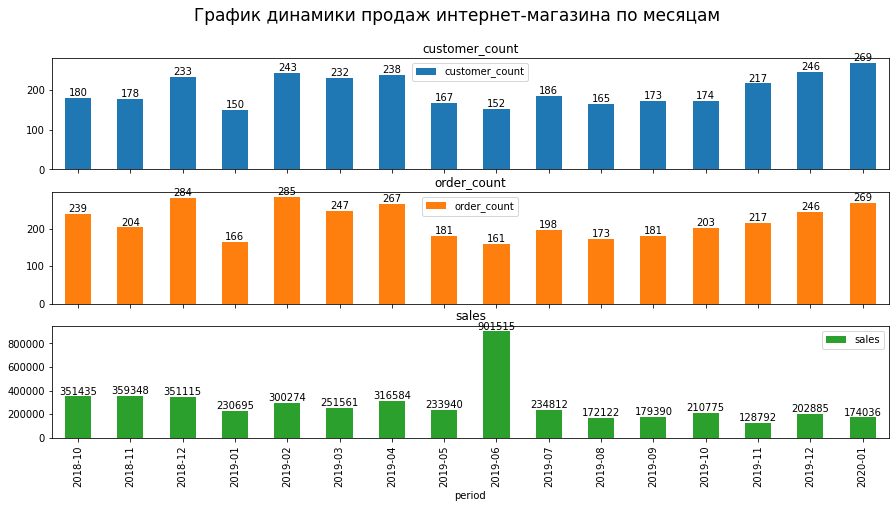

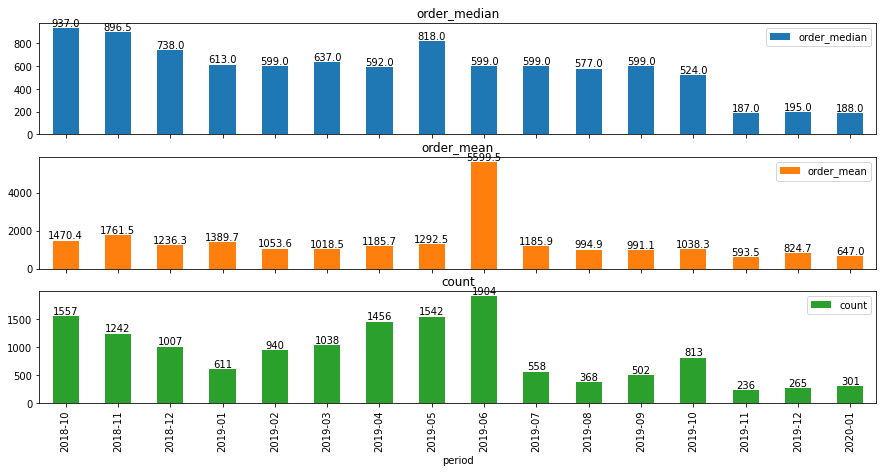

,customer_count,order_count,sales,order_median,order_mean,count
count,16.00,16.00,16.00,16.00,16.00,16.00
mean,200.19,220.06,287454.96,581.16,1392.70,896.25
std,38.45,42.73,178436.13,227.25,1159.79,526.76
min,150.00,161.00,128791.75,187.00,593.51,236.00
25%,171.50,181.00,197011.50,563.75,993.97,468.50
50%,183.00,210.50,234376.00,599.00,1119.65,876.50
75%,234.25,252.00,325216.75,662.25,1316.80,1295.50
max,269.00,285.00,901515.00,937.00,5599.47,1904.00


In [24]:
# строим график динамики продаж по месяцам
# первая часть 
ax1= (orders_year.drop(['order_median','order_mean','count'],axis=1)
     .plot(kind='bar',x = 'period', subplots=True,
           figsize = (15,7))
)

# добавление аннотаций 
for i, (period, customers) in enumerate(zip(orders_year['period'], orders_year['customer_count'])):
    ax1[0].annotate(customers, xy=(i, orders_year['customer_count'].iloc[i]), 
                   ha='center', va='bottom')

for i, (period, order) in enumerate(zip(orders_year['period'], orders_year['order_count'])):
    ax1[1].annotate(order, xy=(i, orders_year['order_count'].iloc[i]), 
                   ha='center', va='bottom')
    
for i, (period, sales) in enumerate(zip(orders_year['period'], orders_year['sales'])):
    ax1[2].annotate(f'{sales:.0f}', xy=(i, orders_year['sales'].iloc[i]), 
                   ha='center', va='bottom')
    
plt.suptitle('График динамики продаж интернет-магазина по месяцам', fontsize=17)
plt.show()

# вторая часть 
ax2= (orders_year.drop(['customer_count','order_count','sales'],axis=1)
     .plot(kind='bar',x = 'period', subplots=True,
           figsize = (15,7))
)
# добавление аннотаций 
for i, (period, median) in enumerate(zip(orders_year['period'], orders_year['order_median'])):
    ax2[0].annotate(f'{median:.1f}', xy=(i, orders_year['order_median'].iloc[i]), 
                   ha='center', va='bottom')

for i, (period, mean) in enumerate(zip(orders_year['period'], orders_year['order_mean'])):
    ax2[1].annotate(f'{mean:.1f}', xy=(i, orders_year['order_mean'].iloc[i]), 
                   ha='center', va='bottom')
    
for i, (period, count) in enumerate(zip(orders_year['period'], orders_year['count'])):
    ax2[2].annotate(f'{count:.0f}', xy=(i, orders_year['count'].iloc[i]), 
                   ha='center', va='bottom')
plt.show()

# статистическая сводка по сводной таблице
orders_year.describe()

**Наблюдения:**

- Наблюдается явный сезонный всплеск продаж в июне, при средней выручке в месяц  234 376 руб., в июне сумма продаж составила 901 515 руб.

- при этом, среднее кол-во покупателей в месяц 183, явных приростов и падений покупателей не наблюдается. в июне было покупателей ниже среднего, 152 клиента.

- количество заказов также без резких скачков и падений, при среднем кол-ве заказов 210 в месяц, в июне было меньше всего  161 заказ. 

- в июне средний чек самый высокий 5599.47 руб., при среднем чеке в месяц 1119.65 руб.

- однако медиана чека в месяц , в том числе в июне составляет 599 руб.

Исходя из выше перечисленного можно сделать вывод, что всплеск продаж в июне возник из-за нетипично больших заказов некоторых покупателей.

Если смотреть в динамике на выручку , медианный чек и проданное кол-во товаров, то наблюдается тенденция на плавное снижение продаж с ноября 2018 по январь 2019 , далее повышение продаж с февраля 2019 по июнь 2019. С июля 2019 увеличивается кол-во покупателей, но снижается качество покупки, покупатели стали более дешевые товары покупать и в меньшем количестве, о чем свидетельствует падение медианного чека и кол-во купленного товара.

Нетипичные заказы  и падение продаж может быть связано с периодом пандемии в 2019 году. В период эзоляции покупатели закупались и многие переехали в дома ближе к природе. После частичного снятия изоляции, многие также перестривали уклад жизни.


### Анализ поведения покупателей.


#### Общие показатели продаж по месяцам, в пересчете на покупателя.


In [25]:
# сводная таблица по пользователям колво заказов, выручка и другие показатели , в разрезе по месяцам
customer = (orders.groupby(['year_month','customer_id'])
            .agg({'order_id':'count','revenue':['sum','median','mean'],'quantity':'mean'})
            .reset_index())
customer.columns = ['period','customer_id','order_count','sales','order_median','order_mean','count_mean']
customer.sort_values(by='order_count',ascending=False).head(10)

,period,customer_id,order_count,sales,order_median,order_mean,count_mean
535,2018-12,c971fb21-d54c-4134-938f-16b62ee86d3b,43,43993.00,749.00,1023.09,1.42
58,2018-10,4d93d3f6-8b24-403b-a74b-f5173e40d7db,35,57278.00,1049.00,1636.51,8.83
919,2019-02,c971fb21-d54c-4134-938f-16b62ee86d3b,28,44806.00,899.00,1600.21,2.39
135,2018-10,c971fb21-d54c-4134-938f-16b62ee86d3b,21,28239.00,896.00,1344.71,5.86
326,2018-11,c971fb21-d54c-4134-938f-16b62ee86d3b,20,24981.00,907.50,1249.05,2.95
2378,2019-10,73d1cd35-5e5f-4629-8cf2-3fda829d4e58,17,21361.00,697.00,1256.53,1.00
1172,2019-03,c971fb21-d54c-4134-938f-16b62ee86d3b,8,8681.00,529.00,1085.12,2.25
702,2019-01,c971fb21-d54c-4134-938f-16b62ee86d3b,6,8808.00,595.50,1468.00,1.00
1383,2019-04,b7b865ab-0735-407f-8d0c-31f74d2806cc,4,3119.00,839.50,779.75,15.75
1603,2019-05,e0535076-6270-4df2-8621-cb06264a94fa,4,636.00,190.50,159.00,1.00


In [26]:
# расчет показателей продаж в динамике в пересчете на одного покупателя 
customer_year = (customer.groupby('period')
                 .agg({'order_count':['mean'],'order_median':'median',
                       'order_mean':'mean','count_mean':'mean'})
                 .reset_index())
customer_year.columns = ['period','order_count_mean','order_median','order_mean','count_mean']
customer_year

,period,order_count_mean,order_median,order_mean,count_mean
0,2018-10,1.33,955.50,1464.89,6.18
1,2018-11,1.15,903.25,1826.42,6.59
2,2018-12,1.22,734.00,1267.59,3.95
3,2019-01,1.11,659.50,1280.17,3.76
4,2019-02,1.17,592.00,1030.24,3.49
5,2019-03,1.06,644.50,1035.11,4.30
6,2019-04,1.12,595.50,1093.76,5.16
7,2019-05,1.08,898.00,1331.67,8.71
8,2019-06,1.06,587.50,5831.49,12.33
9,2019-07,1.06,607.00,1223.53,2.78


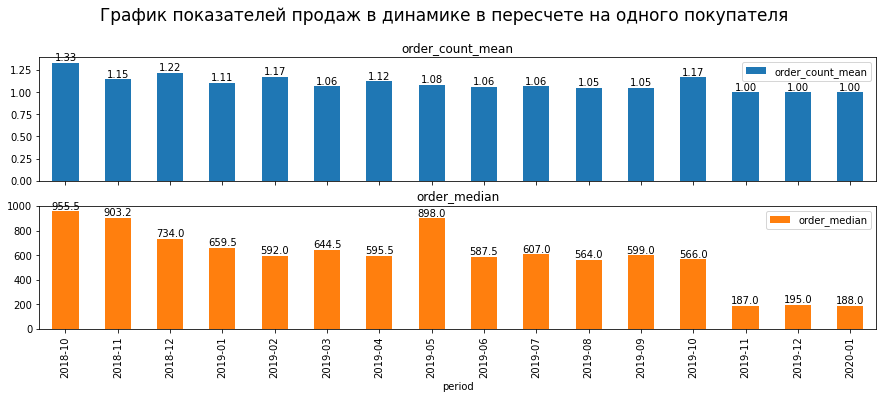

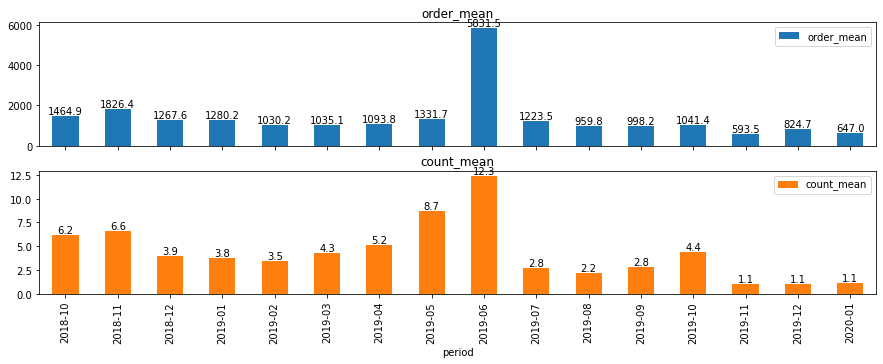

,order_count_mean,order_median,order_mean,count_mean
count,16.00,16.00,16.00,16.00
mean,1.10,592.23,1403.09,4.37
std,0.09,236.18,1218.95,2.99
min,1.00,187.00,593.51,1.08
25%,1.05,565.50,988.58,2.62
50%,1.07,597.25,1067.58,3.86
75%,1.15,678.12,1293.04,5.41
max,1.33,955.50,5831.49,12.33


In [27]:
# строим график показателей продаж в динамике в пересчете на одного покупателя 
# первая часть
ax1= (customer_year.drop(['order_mean','count_mean'],axis=1 )
     .plot(kind='bar',x = 'period', subplots=True,
      figsize = (15,5))
)


# добавление аннотаций 
for i, (period, sales) in enumerate(zip(customer_year['period'], customer_year['order_count_mean'])):
    ax1[0].annotate(f'{sales:.2f}', xy=(i, customer_year['order_count_mean'].iloc[i]), 
                   ha='center', va='bottom')

for i, (period, sales) in enumerate(zip(customer_year['period'], customer_year['order_median'])):
    ax1[1].annotate(f'{sales:.1f}', xy=(i, customer_year['order_median'].iloc[i]), 
                   ha='center', va='bottom')

plt.suptitle('График показателей продаж в динамике в пересчете на одного покупателя', fontsize=17,y=1.02)
plt.show()

# вторая часть  
ax2= (customer_year.drop(['order_count_mean','order_median'],axis=1 )
     .plot(kind='bar',x = 'period', subplots=True,
      figsize = (15,5))
)

# добавление аннотаций 
for i, (period, sales) in enumerate(zip(customer_year['period'], customer_year['order_mean'])):
    ax2[0].annotate(f'{sales:.1f}', xy=(i, customer_year['order_mean'].iloc[i]), 
                   ha='center', va='bottom')
    
for i, (period, sales) in enumerate(zip(customer_year['period'], customer_year['count_mean'])):
    ax2[1].annotate(f'{sales:.1f}', xy=(i, customer_year['count_mean'].iloc[i]), 
                   ha='center', va='bottom')
plt.show()

# статистическая сводка по сводной таблице
customer_year.describe()

**Наблюдения:**

- в среднем на покупателя приходится 1 заказ
- в среднем в чеке 3-4 штуки товаров
- средний чек 1067.58 руб, выше медианного 597.25 руб. почти в 2 раза, что опять же свидетельствует о некскольких покупателях с нетипычными заказами


Наблюдается аналогичная ситуация, всплеск среднего чека в июне 2019 года, при стабильном медианном чеке. А также общее плавное снижение всех показателей  июня 2019 года.

#### Гистрограма распределения выручки с клиента за весь период

In [28]:
# сводная таблица по каждому пользователю за весь период кол-во заказов, выручка, средний чек, средний прайс
customers = (orders.groupby('customer_id')
             .agg({'order_id':'count','quantity':['sum','median','mean'],
                   'revenue':['sum','mean'],'mean_price':'mean'})
             .reset_index())
customers.columns = ['customer_id','order_count','count_total','count_median','count_mean',
                     'sales','order_mean','price_mean']
customers.sort_values(by='order_mean').head()

,customer_id,order_count,count_total,count_median,count_mean,sales,order_mean,price_mean
328,2330d859-e9cb-4c8f-abd0-55f9e27e6745,1,1,1.00,1.00,15.00,15.00,15.00
402,2b6439c9-1ae1-4785-9509-ca4348b3d39a,1,1,1.00,1.00,22.00,22.00,22.00
165,10f79846-2640-4c43-8392-4e76ff5455ef,1,1,1.00,1.00,22.00,22.00,22.00
2253,eec973c9-6ae9-4c1b-b1c7-a2718fde2f84,1,1,1.00,1.00,22.00,22.00,22.00
2066,da6f7bf7-f699-4046-a4dd-cab0c27debcb,1,1,1.00,1.00,22.00,22.00,22.00


In [29]:
orders.head()

,customer_id,order_id,year_month,date,quantity,revenue,mean_price
0,000d6849-084e-4d9f-ac03-37174eaf60c4,14943,2019-10,2019-10-16 08:00:00,4,555.00,138.75
1,001cee7f-0b29-4716-b202-0042213ab038,70290,2019-02,2019-02-16 11:00:00,1,442.00,442.00
2,00299f34-5385-4d13-9aea-c80b81658e1b,72965,2019-10,2019-10-14 23:00:00,2,914.00,457.00
3,002d4d3a-4a59-406b-86ec-c3314357e498,69990,2019-01,2019-01-27 17:00:00,1,1649.00,1649.00
4,003bbd39-0000-41ff-b7f9-2ddaec152037,72796,2019-09,2019-09-29 17:00:00,2,2324.00,1162.00


In [30]:
# статистическая сводка по колонке
customers['sales'].describe()

count     2430.00
mean      1892.71
std      14328.68
min         15.00
25%        389.00
50%        832.00
75%       1798.00
max     675000.00
Name: sales, dtype: float64

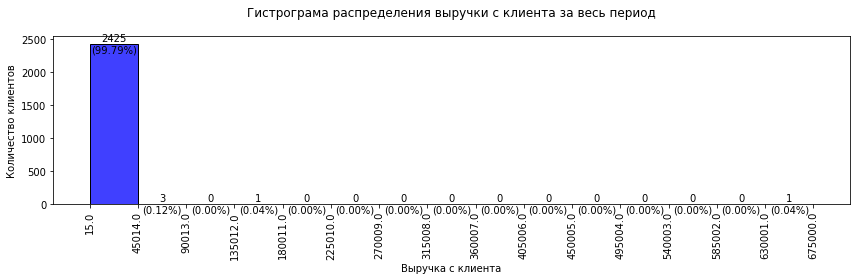

In [31]:
# cоздание гистограммы
plt.figure(figsize=(12,4))
ax = sns.histplot(customers['sales'], bins=15, color='blue')

# общее количетсво пользователей 
total_customers = len(customers)

# добавляем подписи данных
for p in ax.patches:
    height = p.get_height() #  подсчет кол-ва пользователей
    percentage = (height/total_customers)*100  # процент пользователей
    ax.annotate(f'{int(height)}\n({percentage:.2f}%)', # подписи: количество и процент 
               (p.get_x() + p.get_width()/2.,height), # позиция текста 
                ha='center', va='center', # выравнивание текста
                xytext=(0,0.5), # смещение тектса
                textcoords='offset points') # система координат для смещения
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)

# подписи графика
plt.title('Гистрограма распределения выручки с клиента за весь период', pad=20)
plt.xlabel('Выручка с клиента')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

**Обнаружен 1 клиент с нетипичной выручкой по заказам 675 000 руб., при медианной выручке с клиента 832 руб. Это может быть технической сбой в выгрузке данных.**

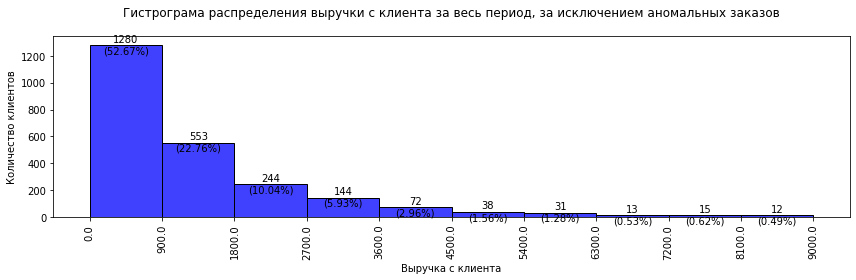

In [32]:
# создание гистограммы
plt.figure(figsize=(12,4))
ax = sns.histplot(customers['sales'], bins=10, color='blue',binrange=(0, 9000))


# добавляем подписи данных
for p in ax.patches:
    height = p.get_height() #  подсчет кол-ва пользователей
    percentage = (height/total_customers)*100  # процент пользователей
    ax.annotate(f'{int(height)}\n({percentage:.2f}%)', # подписи: количество и процент 
               (p.get_x() + p.get_width()/2.,height), # позиция текста 
                ha='center', va='center', # выравнивание текста
                xytext=(0,0.5), # смещение тектса
                textcoords='offset points') # система координат для смещения
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)

# подписи графика
plt.title('Гистрограма распределения выручки с клиента за весь период, за исключением аномальных заказов', pad=20)
plt.xlabel('Выручка с клиента')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

**Налюдение:**

52,67 % покупателей принесли за весь период интернет -магазину выручку в размере до 900 руб., 22,8% 900 - 1800 руб. , 10 % 1800 - 2700 руб. Остальные клиенты свыше 2700 руб.

####  Гистрограма распределения средней суммы чека  клиента.

In [33]:
# статистическая сводка по колонке
customers['order_mean'].describe()

count     2430.00
mean      1442.21
std      13829.77
min         15.00
25%        300.00
50%        642.50
75%       1345.50
max     675000.00
Name: order_mean, dtype: float64

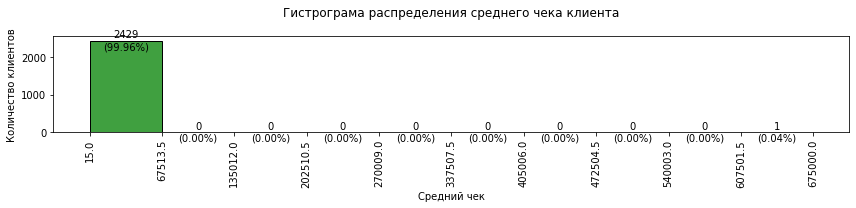

In [34]:
# создание гистограммы
plt.figure(figsize=(12,3))
ax = sns.histplot(customers['order_mean'],bins=10, color= 'green')


# добавляем подписи данных
for p in ax.patches:
    height = p.get_height() #  подсчет кол-ва пользователей
    percentage = (height/total_customers)*100  # процент пользователей
    ax.annotate(f'{int(height)}\n({percentage:.2f}%)', # подписи: количество и процент 
               (p.get_x() + p.get_width()/2.,height), # позиция текста 
                ha='center', va='center', # выравнивание текста
                xytext=(0,0.5), # смещение тектса
                textcoords='offset points') # система координат для смещения
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)

# подписи графика
plt.title('Гистрограма распределения среднего чека клиента', pad=20)
plt.xlabel('Средний чек')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

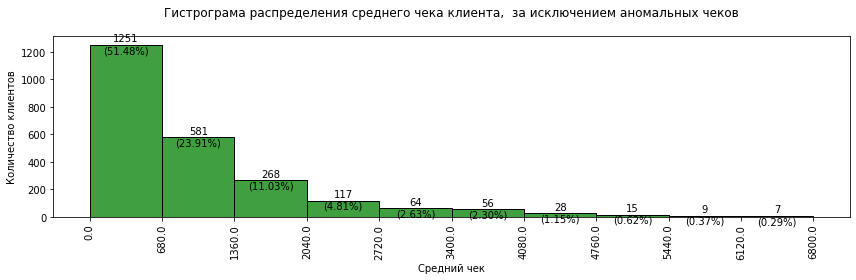

In [35]:
# создание гистограммы
plt.figure(figsize=(12,4))
ax = sns.histplot(customers['order_mean'], bins=10, color='green', binrange=(0, 6800))


# добавляем подписи данных
for p in ax.patches:
    height = p.get_height() #  подсчет кол-ва пользователей
    percentage = (height/total_customers)*100  # процент пользователей
    ax.annotate(f'{int(height)}\n({percentage:.2f}%)', # подписи: количество и процент 
               (p.get_x() + p.get_width()/2.,height), # позиция текста 
                ha='center', va='center', # выравнивание текста
                xytext=(0,0.5), # смещение тектса
                textcoords='offset points') # система координат для смещения
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)

# подписи графика
plt.title('Гистрограма распределения среднего чека клиента,  за исключением аномальных чеков', pad=20)
plt.xlabel('Средний чек')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

**Налюдение:**

У 51,5 % покупателей средний чек в размере до 680 руб., 24% 680 - 1360 руб. , 11 % 1360 - 2040 руб. Остальные клиенты свыше 2040 руб.

И найден 1 клиент с нетипичным средним чеком 675 000 руб.

####  Гистрограма распределения количества заказов на клиента.

In [36]:
# статистическая сводка по колонке
customers['order_count'].describe()

count   2430.00
mean       1.45
std        2.69
min        1.00
25%        1.00
50%        1.00
75%        2.00
max      126.00
Name: order_count, dtype: float64

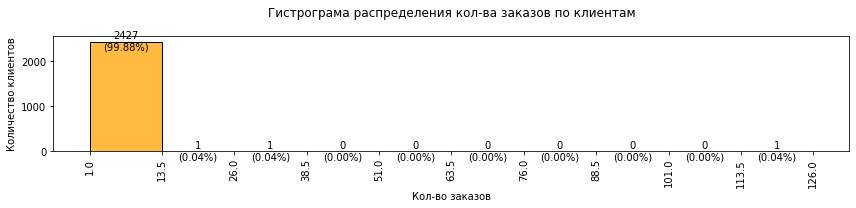

In [37]:
# создание гистограммы
plt.figure(figsize=(12,3))
ax = sns.histplot(customers['order_count'], bins=10, color='orange')


# добавляем подписи данных
for p in ax.patches:
    height = p.get_height() #  подсчет кол-ва пользователей
    percentage = (height/total_customers)*100  # процент пользователей
    ax.annotate(f'{int(height)}\n({percentage:.2f}%)', # подписи: количество и процент 
               (p.get_x() + p.get_width()/2.,height), # позиция текста 
                ha='center', va='center', # выравнивание текста
                xytext=(0,0.5), # смещение тектса
                textcoords='offset points') # система координат для смещения
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)

# подписи графика
plt.title('Гистрограма распределения кол-ва заказов по клиентам', pad=20)
plt.xlabel('Кол-во заказов')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

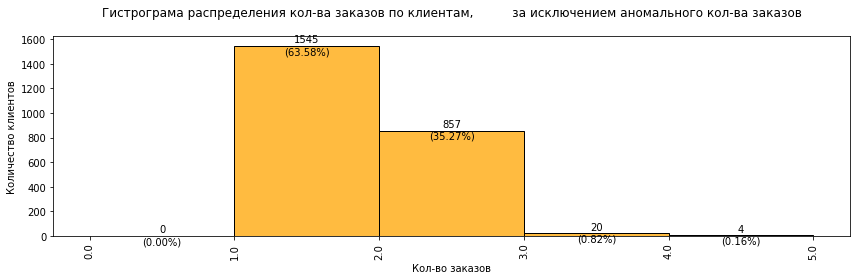

In [38]:
# создание гистограммы
plt.figure(figsize=(12,4))
ax = sns.histplot(customers['order_count'], bins=5, color='orange',binrange=(0, 5))


# добавляем подписи данных
for p in ax.patches:
    height = p.get_height() #  подсчет кол-ва пользователей
    percentage = (height/total_customers)*100  # процент пользователей
    ax.annotate(f'{int(height)}\n({percentage:.2f}%)', # подписи: количество и процент 
               (p.get_x() + p.get_width()/2.,height), # позиция текста 
                ha='center', va='center', # выравнивание текста
                xytext=(0,0.5), # смещение тектса
                textcoords='offset points') # система координат для смещения
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)

# подписи графика
plt.title('Гистрограма распределения кол-ва заказов по клиентам,\
          за исключением аномального кол-ва заказов', pad=20)
plt.xlabel('Кол-во заказов')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

**Наблюдение:**

Обнаружен также 1 покупатель с нетипичным кол-вом заказов 126 покупок.Это может быть технически созданный покупатель для проведения тестов по заказам.

Основная масса покупателей сделала по 1 заказу, таких 63,5% покупателей. 35,27% покупателей оформили 2 заказа.Оставшиеся 1,15% сделали свыше 3-ех заказов.

####  Гистрограма распределения среднего количества штук в заказе.

In [39]:
# статистическая сводка по колонке
customers['count_mean'].describe()

count   2430.00
mean       4.96
std       25.29
min        1.00
25%        1.00
50%        1.00
75%        3.00
max     1000.00
Name: count_mean, dtype: float64

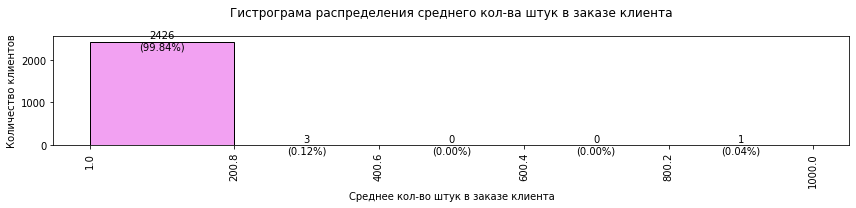

In [40]:
# создание гистограммы
plt.figure(figsize=(12,3))
ax = sns.histplot(customers['count_mean'], bins=5, color='violet')


# добавляем подписи данных
for p in ax.patches:
    height = p.get_height() #  подсчет кол-ва пользователей
    percentage = (height/total_customers)*100  # процент пользователей
    ax.annotate(f'{int(height)}\n({percentage:.2f}%)', # подписи: количество и процент 
               (p.get_x() + p.get_width()/2.,height), # позиция текста 
                ha='center', va='center', # выравнивание текста
                xytext=(0,0.5), # смещение тектса
                textcoords='offset points') # система координат для смещения
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)

# подписи графика
plt.title('Гистрограма распределения среднего кол-ва штук в заказе клиента', pad=20)
plt.xlabel('Среднее кол-во штук в заказе клиента')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

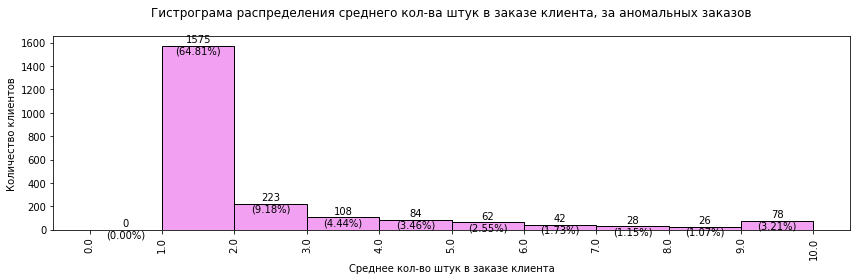

In [41]:
# создание гистограммы
plt.figure(figsize=(12,4))
ax = sns.histplot(customers['count_mean'], bins=10, color='violet',binrange=(0, 10))


# добавляем подписи данных
for p in ax.patches:
    height = p.get_height() #  подсчет кол-ва пользователей
    percentage = (height/total_customers)*100  # процент пользователей
    ax.annotate(f'{int(height)}\n({percentage:.2f}%)', # подписи: количество и процент 
               (p.get_x() + p.get_width()/2.,height), # позиция текста 
                ha='center', va='center', # выравнивание текста
                xytext=(0,0.5), # смещение тектса
                textcoords='offset points') # система координат для смещения
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)

# подписи графика
plt.title('Гистрограма распределения среднего кол-ва штук в заказе клиента, за аномальных заказов', pad=20)
plt.xlabel('Среднее кол-во штук в заказе клиента')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

**Наблюдение:**

65% покупателей заказали только 1 товар.  у 9% покупателей  2 товара в чеке. 4,4% положили в заказ 3 товара.

У одного покупателя в чеке было 1000 штук. Это может быть тот же виртуальный покупатель для проведения тестов или техническая ошибка.

####  Определение интервала между покупками. Гистрограма интервала между покупками.

In [42]:
# сортируем данные по пользователю и дате заказа
orders = orders.sort_values(['customer_id', 'date'])

# группируем по пользователю и вычисляем разницу между заказами
orders['days_between_orders'] = orders.groupby('customer_id')['date'].diff().dt.days
# статистическая сводка по колонке
display(orders['days_between_orders'].describe())
display(orders.head(10))

count   1091.00
mean     177.44
std      136.53
min        0.00
25%        2.50
50%      197.00
75%      295.00
max      395.00
Name: days_between_orders, dtype: float64

,customer_id,order_id,year_month,date,quantity,revenue,mean_price,days_between_orders
0,000d6849-084e-4d9f-ac03-37174eaf60c4,14943,2019-10,2019-10-16 08:00:00,4,555.00,138.75,NaN
1,001cee7f-0b29-4716-b202-0042213ab038,70290,2019-02,2019-02-16 11:00:00,1,442.00,442.00,NaN
2,00299f34-5385-4d13-9aea-c80b81658e1b,72965,2019-10,2019-10-14 23:00:00,2,914.00,457.00,NaN
3,002d4d3a-4a59-406b-86ec-c3314357e498,69990,2019-01,2019-01-27 17:00:00,1,1649.00,1649.00,NaN
4,003bbd39-0000-41ff-b7f9-2ddaec152037,72796,2019-09,2019-09-29 17:00:00,2,2324.00,1162.00,NaN
5,004d24e9-4a6c-4d0e-8727-8391dfd4b43a,69987,2019-01,2019-01-27 12:00:00,12,1536.00,128.00,NaN
6,005ba170-45e8-42de-93f7-192481ae2659,68803,2018-10,2018-10-30 20:00:00,1,1199.00,1199.00,NaN
7,005ba170-45e8-42de-93f7-192481ae2659,105120,2019-11,2019-11-05 21:00:00,2,6658.00,3329.00,371.00
8,00bd74b1-2792-47db-a2f1-680a09ac5026,68706,2018-10,2018-10-21 05:00:00,1,937.00,937.00,NaN
9,00c0f92a-121a-4883-a78d-2c7b5fe187de,70418,2019-02,2019-02-23 16:00:00,1,134.00,134.00,NaN


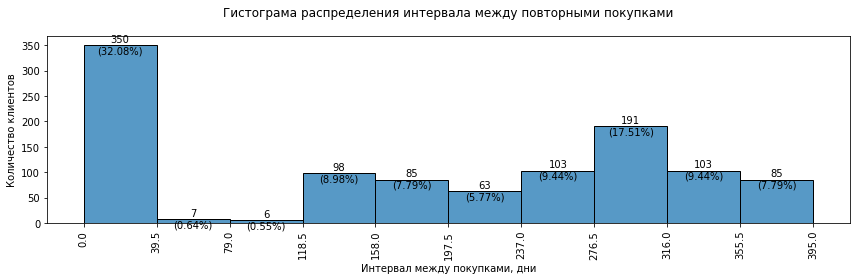

In [43]:
# cоздание гистограммы
plt.figure(figsize=(12,4))
ax = sns.histplot(orders['days_between_orders'], bins=10)

# общее количетсво заказов
total_customers = len(orders.dropna(subset=['days_between_orders']))

# Добавляем подписи данных
for p in ax.patches:
    height = p.get_height() #  подсчет кол-ва пользователей
    percentage = (height/total_customers)*100  # процент пользователей
    ax.annotate(f'{int(height)}\n({percentage:.2f}%)', # подписи: количество и процент 
               (p.get_x() + p.get_width()/2.,height), # позиция текста 
                ha='center', va='center', # выравнивание текста
                xytext=(0,0.5), # смещение тектса
                textcoords='offset points') # система координат для смещения
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)

# подписи графика
plt.title('Гистограма распределения интервала между повторными покупками', pad = 20)
plt.xlabel('Интервал между покупками, дни')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

**Наблюдение:**

Из всех покупателей , совершивших повторные покупки, 32% сделаи повторный заказ в течение 40 дней, 17,5% сделали повторынй заказ в промежутке от 276 до 316 дней между заказами.Медианный интервал между покупками 197 дней. 
Любопытно, что 32 % в течение 40 дней делают покупки, остальные в промежутке от 4 месяцев до года. Похоже на то, что если покупатель возвращается, то за определенными сезонными товарами.

#### Определение , есть ли зависимость частоты покупок от суммы заказа.

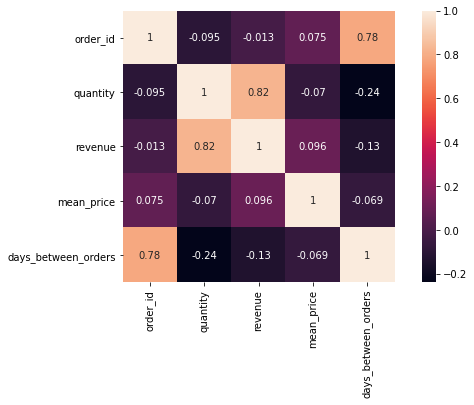

In [44]:
#построим и отрисуем матрицу корреляций

cm = orders.corr() #вычисляем матрицу корреляций
plt.figure(figsize=(10,5))

#нарисуем тепловую карту с подписями для матрицы корреляций
sns.heatmap(cm, annot=True, square=True)
plt.show()

**Наблюдение:**

Интервал повторной покупки с суммой  заказа не имеет корреляцию. Наблюдается только значимая корреляция 0,82 суммы чека и кол-ва товара в чеке, что логично.

### Анализ категорий.

#### Рейтинг категорий. Выявление топ - n  категорий.

In [45]:
# сводная таблица с продажами по категориям
categories = data.groupby('category').agg({'revenue':'sum','quantity':'sum','product':'nunique'})
categories = categories.sort_values(by='revenue',ascending=False).reset_index()
categories.columns = ['category','sales','count','sku_count']
categories['part'] = categories['sales']/categories['sales'].sum()
categories['cumulative_part'] = categories['part'].cumsum()
categories

,category,sales,count,sku_count,part,cumulative_part
0,Оборудование для хоз. работ,940857.25,498,139,0.20,0.20
1,"Сантехника, все для ванной комнаты",894772.00,1358,119,0.19,0.40
2,"Сушилки, гладильные доски",708069.17,641,239,0.15,0.55
3,"Цветы, растения",430479.83,2236,485,0.09,0.65
4,"Хоз.товары, для уборки",302919.50,1067,128,0.07,0.71
5,Товары для кухни,296864.00,1363,278,0.06,0.78
6,"Мебель, интерьер, фурнитура",227777.50,845,93,0.05,0.83
7,"Постельное белье, и текстиль",221966.00,210,70,0.05,0.87
8,Вешалки и хранение вещей,219038.00,1315,115,0.05,0.92
9,"Рассада, саженцы",155345.50,1832,450,0.03,0.96


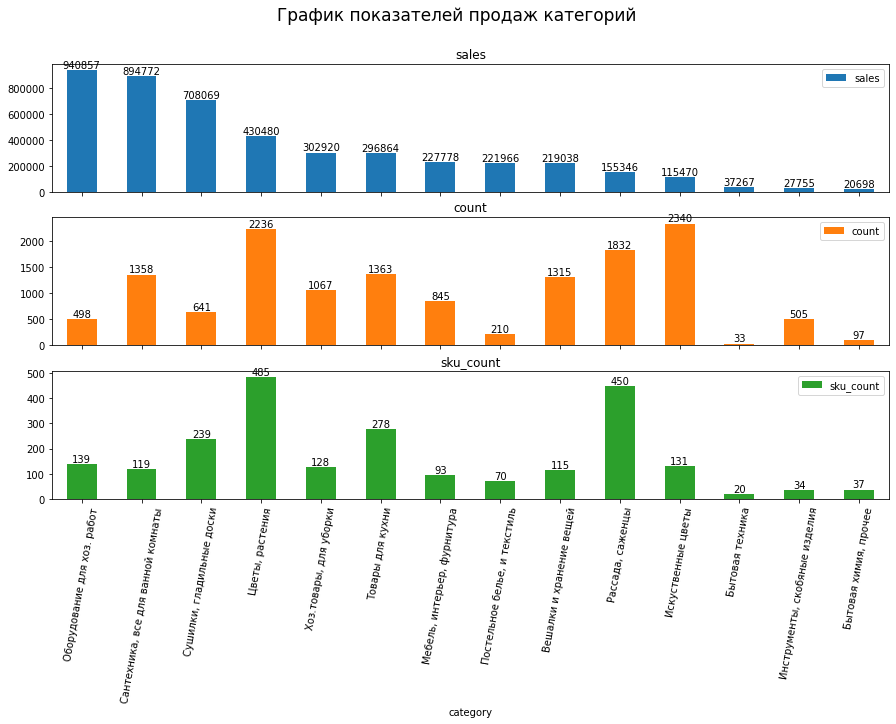

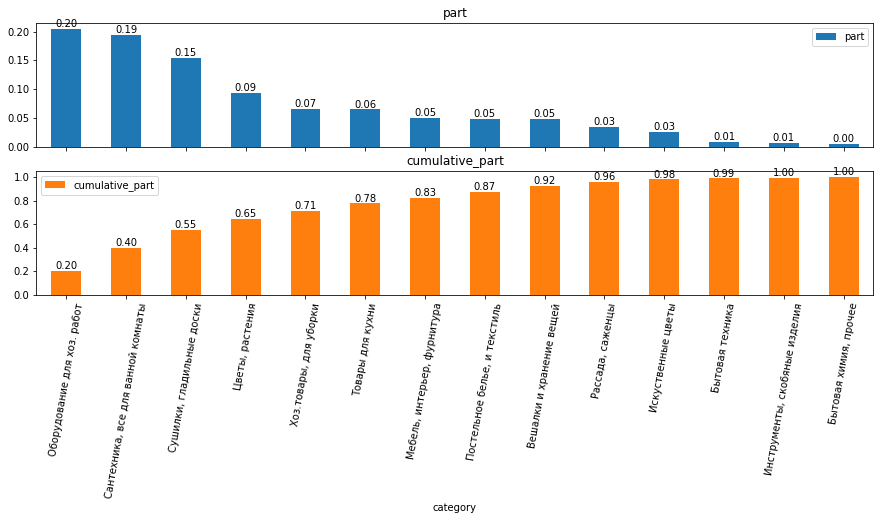

In [46]:
# строим график по продажам по категориям
# первый график
ax1= (categories.drop(['part','cumulative_part'],axis=1)
     .plot(kind='bar',x = 'category', subplots=True,
      figsize = (15,8))
)

# добавление аннотаций 
for i, (category, sales) in enumerate(zip(categories['category'], categories['sales'])):
    ax1[0].annotate(f'{sales:.0f}', xy=(i, sales), ha='center', va='bottom')

for i, (category, sales) in enumerate(zip(categories['category'], categories['count'])):
    ax1[1].annotate(f'{sales:.0f}', xy=(i, sales), ha='center', va='bottom')    
    
for i, (category, count) in enumerate(zip(categories['category'], categories['sku_count'])):
    ax1[2].annotate(f'{count:.0f}', xy=(i, count), ha='center', va='bottom')
    
plt.suptitle('График показателей продаж категорий', fontsize=17)
plt.xticks(rotation=80)
plt.show()

# второй график
ax2= (categories.drop(['sales','count','sku_count'],axis=1)
     .plot(kind='bar',x = 'category', subplots=True,
      figsize = (15,5))
)

# добавление аннотаций 
for i, (category, count) in enumerate(zip(categories['category'], categories['part'])):
    ax2[0].annotate(f'{count:.2f}', xy=(i, count), ha='center', va='bottom')
    
for i, (category, count) in enumerate(zip(categories['category'], categories['cumulative_part'])):
    ax2[1].annotate(f'{count:.2f}', xy=(i, count), ha='center', va='bottom')
    
plt.xticks(rotation=80)
plt.show()

**Наблюдение:**

1. Можно выделить несколько ведущих категорий, на которых специализируется интернет-магазин, по широте ассортимента:
- Цветы, растения 485 скю
- Рассада, саженцы 450 скю
- Товары для кухни 278 скю
- Сушилки, гладильные доски 239 скю
- Оборудование для хоз. работ  139 скю

2. Но самые выгодные категории, которые принесли 80% прибыли:

- Оборудование для хоз. работ 940 857 руб.
- Сантехника, все для ванной комнаты 894 772 руб. 
- Сушилки, гладильные доски 708 069 руб.
- Цветы, растения 430 479 руб.
- Хоз.товары, для уборки 302 919 руб. 
- Товары для кухни 296 864 руб.

3. Категории, в которых продано 80% от всего проданного количества: 
- Иcкуственные цветы 2340 шт. 
- Цветы, растения 2236 шт.
- Рассада, саженцы 1832 шт.
- Товары для кухни 1363 шт.
- Сантехника, все для ванной комнаты 1358 шт.
- Вешалки и хранение вещей 1315 шт.
- Хоз.товары, для уборки  1067 шт.

Объдинив продажи в рублях и по кол-ву можно выделить ведущие категории:

Сантехника и все для ванной комнаты, Цветы и растени, Хоз.товары для уборки, Товары для кухни.

#### Диаграмма размаха среднего чека по каждой категории

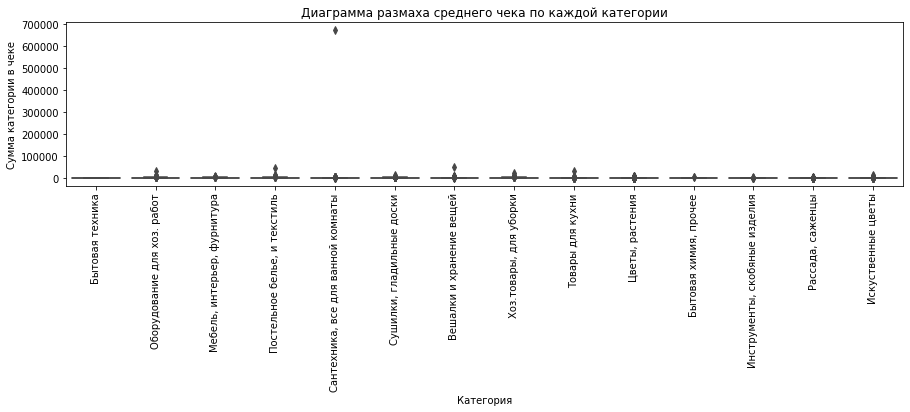

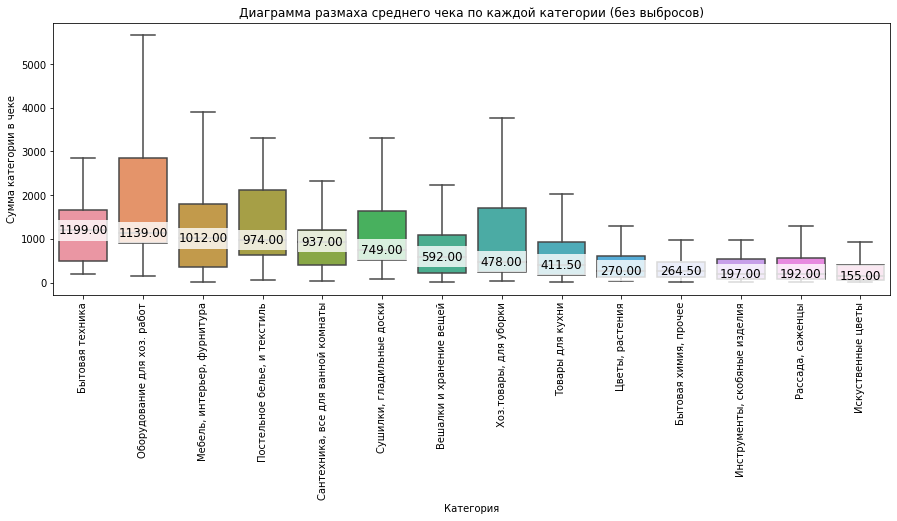

In [47]:
# формирование таблицы из каких категорий состоит чек, сумма категории в чеке
categories_order = data.groupby(['category','order_id']).agg({'revenue':'sum'}).reset_index()

# строим диаграмму размаха по продажам в разрезе категорий
plt.figure(figsize=(15, 3))
sns.boxplot(x='category', y='revenue', data=categories_order,
           order = categories_order.groupby('category')['revenue']
            .median().sort_values(ascending=False).index)# сортировка категорий для вывода по убыванию
plt.title('Диаграмма размаха среднего чека по каждой категории')
plt.xlabel('Категория')
plt.xticks(rotation=90)
plt.ylabel('Сумма категории в чеке')
plt.show()


# диаграмма размаха за исключением выбросов 

plt.figure(figsize=(15,5))
ax = sns.boxplot(x='category', y='revenue', data=categories_order, showfliers=False,
            order = categories_order.groupby('category')['revenue']
            .median().sort_values(ascending=False).index)

# получаем заранее отсортированные медианы
medians = categories_order.groupby('category')['revenue'].median().sort_values(ascending=False)

# добавляем подписи медиан
for i, category in enumerate(medians.index):
    ax.text(i, medians[category], f'{medians[category]:.2f}', 
            ha='center', va='center', 
            fontsize=12, color='black',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.xticks(rotation=90)
plt.title('Диаграмма размаха среднего чека по каждой категории (без выбросов)')
plt.xlabel('Категория')
plt.ylabel('Сумма категории в чеке')
plt.show()

Топ-5 самых дорогих категорий по  чеку:
- Бытовая техника ,чаще всего тратили в заказе 1199 руб.
- Оборудование для хоз. работ ,чаще всего тратили в заказе 1139 руб.
- Мебель, интерьер, фурнитура, чаще всего тратили в заказе 1012 руб.
- Постельное белье, и текстиль, чаще всего тратили в заказе 974 руб.
- Сантехника, все для ванной комнаты, чаще всего тратили в заказе 937 руб.

Самые дешевые категории:
- Рассада и саженцы, чаще всего тратили в заказе 192 руб.
- Искуственные цветы, чаще всего тратили в заказе 155 руб.

#### Динамика продаж категорий по месяцам. Определение сезонности.

In [48]:
# сводная таблица с продажами по категориям в динамике по месяцам
categories_year = data.groupby(['year_month','category']).agg({'revenue':'sum','quantity':'sum'}).reset_index()
categories_year.columns = ['period','category','sales','count']
categories_year.head()

,period,category,sales,count
0,2018-10,Бытовая техника,2248.00,2
1,2018-10,"Бытовая химия, прочее",1089.00,7
2,2018-10,Вешалки и хранение вещей,25288.00,229
3,2018-10,Иcкуственные цветы,11393.00,216
4,2018-10,"Инструменты, скобяные изделия",4757.00,230


In [49]:
# преобразовываем тип данных для построения графика
categories_year['period'] = categories_year['period'].astype(str)

# строим график по выручке
fig = px.bar(categories_year,
             x='period',
             y='sales',
             color='category',
             color_discrete_sequence=px.colors.qualitative.Light24,
             text='sales'
            )

fig.update_layout(
    title={'text': 'Выручка по категориям в динамике', 'font': {'size': 15}},
    title_x=0.5,
    xaxis_title='Период',
    yaxis_title='Выручка',
    yaxis={'categoryorder': 'total ascending'},
    template="plotly_white",
    
    # настройки легенды:
    legend=dict(
        font=dict(size=10),  # Размер шрифта
        orientation='h',  # Горизонтальное расположение
        yanchor='bottom',  # Якорь снизу
        y=-0.5,  # Смещение ниже графика (отрицательное значение)
        xanchor='center',  # Выравнивание по центру
        x=0.5  # Позиция по горизонтали
    )
)

# форматирование текста на столбцах
fig.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside',
    textfont_size=10  # Размер шрифта значений на столбцах
)

fig.show()




# преобразовываем тип данных для построения графика
categories_year['period'] = categories_year['period'].astype(str)


# строим график по продажам в штуках
fig = px.bar(categories_year,
             x='period',
             y='count',
             color='category',
             color_discrete_sequence=px.colors.qualitative.Light24,
             text='count'  
            )

fig.update_layout(
    title={'text': 'Продажи в штуках по категориям в динамике', 'font': {'size': 15}},
    title_x=0.5,
    xaxis_title='Период',
    yaxis_title='Продажи, шт.',
    yaxis={'categoryorder': 'total ascending'},
    template="plotly_white",
    
    # Настройки легенды:
    legend=dict(
        font=dict(size=10),  # Размер шрифта
        orientation='h',  # Горизонтальное расположение
        yanchor='bottom',  # Якорь снизу
        y=-0.5,  # Смещение ниже графика (отрицательное значение)
        xanchor='center',  # Выравнивание по центру
        x=0.5  # Позиция по горизонтали
    )
)

# Форматирование текста на столбцах
fig.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside',
    textfont_size=10  # Размер шрифта значений на столбцах
)

fig.show()

**Наблюдения:**

 - В июне 2019 года наблюдается резкий скачок продаж категории "сантехника и всё для ванной". Необходимо проверить , не относятся ли эти продажи к выявленным ранее аномальным заказам одного из покупателей.
 - В апреле и мае 2019 года появляются продажи категории "рассада и саженцы", что логично для периода засеивания огородов и садов.
 - В июне также наблюдается увеличение продаж категории "вешалки и хранения вещей". Это можно обосновать тем, что в начале летнего сезона многие складывают на хранение зимние , теплые вещи, достают летний гардероб и меняют сезонную обувь.
 - А на январь 2019 года приходятся основные продажи категории "Постельное белье и текстиль".



In [50]:
# строим линейный график
fig = px.line(
    categories_year,
    x='period',
    y='sales',
    color='category',
    color_discrete_sequence=px.colors.qualitative.Light24,
    markers=True,  # добавляем маркеры к точкам
    line_shape='spline',  # сглаженные линии
    title='Динамика выручки по категориям'
)

# настройки оформления
fig.update_layout(
    title={'text': 'Динамика выручки по категориям', 'font': {'size': 15}},
    title_x=0.5,
    xaxis_title='Период',
    yaxis_title='Выручка',
    yaxis={'categoryorder': 'total ascending'},
    template="plotly_white",
    legend=dict(
        font=dict(size=10),
        orientation='h',
        yanchor='bottom',
        y=-0.5,
        xanchor='center',
        x=0.5
    )
)



fig.show()

###  Обработка выбросов. 

**Перед выявлением сегментов профилей потребления покупателей очистим датасет от пользователей с аномальными заказами. Рассмотрим топ-10 покупателей по сумме заказа, кол-ву штук в заказе и кол-ву заказов.**

In [51]:
# топ-10 покупателей по средней сумме чека
display('Топ-10 покупателей по средней сумме чека',\
        customers.sort_values(by='order_mean',ascending=False).head(10))
# топ-10 покупателей по среднему кол-ву товарных позиций в чеке
display('Топ-10 покупателей по среднему кол-ву товарных позиций в чеке',\
        customers.sort_values(by='count_median',ascending=False).head(10))

'Топ-10 покупателей по средней сумме чека'

,customer_id,order_count,count_total,count_median,count_mean,sales,order_mean,price_mean
462,312e9a3e-5fca-43ff-a6a1-892d2b2d5ba6,1,1000,1000.00,1000.00,675000.00,675000.00,675.00
197,146cd9bf-a95c-4afb-915b-5f6684b17444,1,334,334.00,334.00,49432.00,49432.00,148.00
1347,8fba3604-ef57-4b9f-b2fe-3402fa8825c8,1,101,101.00,101.00,33680.00,33680.00,173.17
982,6987e6d6-a63a-4ce2-a2d0-f424092d235e,1,57,57.00,57.00,32718.00,32718.00,574.00
828,58a4c3cc-504f-43ea-a74a-bae19e665552,2,30,15.00,15.00,53232.00,26616.00,1852.00
265,1b2764ad-9151-4051-a46a-9b01b62e6335,1,5,5.00,5.00,24370.00,24370.00,4874.00
1492,9f1e7d7d-ff10-4eb1-b596-1cbf8075aa3f,1,47,47.00,47.00,22056.00,22056.00,812.38
1354,909564b8-3a5c-4d3e-8310-5ba1c837bbd7,1,3,3.00,3.00,16536.00,16536.00,5512.00
863,5d189e88-d4d6-4eac-ab43-fa65a3c4d106,1,300,300.00,300.00,15300.00,15300.00,51.00
133,0d87f4ae-465a-4fac-81e6-5d629761783e,1,1,1.00,1.00,14917.00,14917.00,14917.00


'Топ-10 покупателей по среднему кол-ву товарных позиций в чеке'

,customer_id,order_count,count_total,count_median,count_mean,sales,order_mean,price_mean
462,312e9a3e-5fca-43ff-a6a1-892d2b2d5ba6,1,1000,1000.00,1000.00,675000.00,675000.00,675.00
197,146cd9bf-a95c-4afb-915b-5f6684b17444,1,334,334.00,334.00,49432.00,49432.00,148.00
1935,cd09ea73-d9ce-48c3-b4c5-018113735e80,1,300,300.00,300.00,8550.00,8550.00,28.50
863,5d189e88-d4d6-4eac-ab43-fa65a3c4d106,1,300,300.00,300.00,15300.00,15300.00,51.00
1570,a984c5b7-ff7e-4647-b84e-ef0b85a2762d,1,200,200.00,200.00,5800.00,5800.00,29.00
1579,aa42dc38-780f-4b50-9a65-83b6fa64e766,1,170,170.00,170.00,8670.00,8670.00,51.00
975,685d3d84-aebb-485b-8e59-344b3df8b3d3,1,150,150.00,150.00,3000.00,3000.00,20.00
124,0c5aaa88-e346-4f87-8f7a-ad8cbc04e965,1,140,140.00,140.00,8260.00,8260.00,59.00
1347,8fba3604-ef57-4b9f-b2fe-3402fa8825c8,1,101,101.00,101.00,33680.00,33680.00,173.17
2056,d933280e-5372-448f-be44-b269c8bafc2a,1,100,100.00,100.00,1900.00,1900.00,19.00


In [52]:
# определение медианы кол-ва товаров в заказе на клиента
customers['count_median'].describe()

count   2430.00
mean       4.95
std       25.29
min        1.00
25%        1.00
50%        1.00
75%        3.00
max     1000.00
Name: count_median, dtype: float64

In [53]:
# выводим заказ с 1000 шт. 
data[data['customer_id']=='312e9a3e-5fca-43ff-a6a1-892d2b2d5ba6']

,date,customer_id,order_id,product,quantity,price,revenue,year_month,category
3787,2019-06-18 15:00:00,312e9a3e-5fca-43ff-a6a1-892d2b2d5ba6,71743,"вантуз с деревянной ручкой d14 см красный, bur...",1000,675.00,675000.00,2019-06,"Сантехника, все для ванной комнаты"


In [54]:
# выводим заказ с 334 шт. 
data[data['customer_id']=='146cd9bf-a95c-4afb-915b-5f6684b17444']

,date,customer_id,order_id,product,quantity,price,revenue,year_month,category
3720,2019-06-11 07:00:00,146cd9bf-a95c-4afb-915b-5f6684b17444,71668,вешалки мягкие для деликатных вещей 3 шт шоколад,334,148.00,49432.00,2019-06,Вешалки и хранение вещей


In [55]:
# выводим заказ с 300 шт. 
data[data['customer_id']=='5d189e88-d4d6-4eac-ab43-fa65a3c4d106']

,date,customer_id,order_id,product,quantity,price,revenue,year_month,category
3354,2019-05-20 21:00:00,5d189e88-d4d6-4eac-ab43-fa65a3c4d106,71478,муляж яблоко 9 см красное,300,51.00,15300.00,2019-05,Иcкуственные цветы


In [56]:
# выводим заказ с 200 шт. 
data[data['customer_id']=='a984c5b7-ff7e-4647-b84e-ef0b85a2762d']

,date,customer_id,order_id,product,quantity,price,revenue,year_month,category
1012,2018-12-10 14:00:00,a984c5b7-ff7e-4647-b84e-ef0b85a2762d,69289,"ручка-скоба рс-100 белая *трибатрон*, 1108035",200,29.00,5800.00,2018-12,"Мебель, интерьер, фурнитура"


**При медиане чека в 642.50 и мединном количестве товаров в чеке 1 штука, в топ-15 покупателей попали несколько оптовых клиентов с заказами от 100 до 1000 шт. в чеке. Клиенты заказывают единичный товар в большом количестве, это может быть фрод или тех.ошибка. Чтобы не обрезать оптовые заказы, примем за норму количества товара в чеке, близкое 3 стандартным отклоенениям: заказы до 100 шт.**

In [57]:
# топ-10 покупателей по кол-ву заказов
display('Топ-10 покупателей по кол-ву заказов',\
        customers.sort_values(by='order_count',ascending=False).head(10))

'Топ-10 покупателей по кол-ву заказов'

,customer_id,order_count,count_total,count_median,count_mean,sales,order_mean,price_mean
1898,c971fb21-d54c-4134-938f-16b62ee86d3b,126,334,1.00,2.65,159508.00,1265.94,1018.11
733,4d93d3f6-8b24-403b-a74b-f5173e40d7db,35,309,1.00,8.83,57278.00,1636.51,771.19
1089,73d1cd35-5e5f-4629-8cf2-3fda829d4e58,17,17,1.00,1.00,21361.00,1256.53,1256.53
1732,b7b865ab-0735-407f-8d0c-31f74d2806cc,7,68,2.00,9.71,3779.00,539.86,98.00
17,0184f535-b60a-4914-a982-231e3f615206,5,57,4.00,11.40,5681.00,1136.20,172.01
690,498f12a4-6a62-4725-8516-cf5dc9ab8a3a,4,85,11.00,21.25,41900.00,10475.00,782.50
2126,e0535076-6270-4df2-8621-cb06264a94fa,4,4,1.00,1.00,636.00,159.00,159.00
1803,bea7a833-2074-42db-bc49-4457abd3c930,4,30,7.50,7.50,4409.00,1102.25,145.62
918,62952c5b-e5ef-4009-a2f9-1ebff401c514,3,11,3.00,3.67,1629.00,543.00,142.60
867,5d566073-92e8-41d1-a2e6-d301ee5ab6d8,3,17,1.00,5.67,434.00,144.67,51.33


In [58]:
# определение медианы кол-ва заказов на клиента
customers['order_count'].describe()

count   2430.00
mean       1.45
std        2.69
min        1.00
25%        1.00
50%        1.00
75%        2.00
max      126.00
Name: order_count, dtype: float64

**По количеству заказов выделяются 3 клиента, один клиент оформил 35 заказов, другой 126 заказов, при медиане в один заказ на покупателя.**

**Чтобы исключить выбросы и не обрезать заказчиков, совершающих частые заказы, применим тот же метод 3 стандартных отклонений, примем за максимально разумное количество 7 заказов, трех покупателей исключаем.**

In [59]:
# создаем список  пользователей с аномальными заказами
customers_anomal = customers.loc[(customers['count_mean'] >= 100) | (customers['order_count'] > 7)]


In [60]:
# убираем пользователей с аномальными суммами чеков и кол-вом товара в чеке
customers_filter = customers[~ customers['customer_id'].isin(customers_anomal['customer_id'])]

## Кластеризация покупателей при помощи машинного обучения методом K-Means.

### Определение признаков для кластеризации. 

In [61]:
# выводим статистические показатели по всем колонкам
customers_filter.describe()

,order_count,count_total,count_median,count_mean,sales,order_mean,price_mean
count,2414.00,2414.00,2414.00,2414.00,2414.00,2414.00,2414.00
mean,1.38,4.38,3.70,3.71,1466.92,1110.36,716.14
std,0.53,8.06,7.27,7.28,2347.19,1692.42,1027.78
min,1.00,1.00,1.00,1.00,15.00,15.00,14.00
25%,1.00,1.00,1.00,1.00,388.00,299.50,134.00
50%,1.00,2.00,1.00,1.00,824.50,637.00,344.00
75%,2.00,3.00,3.00,3.00,1775.75,1304.50,899.50
max,7.00,96.00,96.00,96.00,53232.00,32718.00,14917.00


**Кластеризацию будем проводить по средним показателям покупки, средний чек, среднее кол-во товаров в чеке, средний прайс товара, а также по кол-ву заказов на пользователя. Остальные признаки удалим.**

In [62]:
# удаляем лишние колонки
customers_filter = customers_filter.drop(['count_total','count_median',
                                          'sales'],axis=1)

### Тепловая карта корреляций признаков.

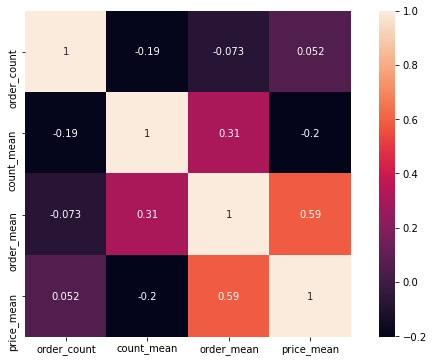

In [63]:
#построим и отрисуем матрицу корреляций

cm = customers_filter.corr() #вычисляем матрицу корреляций
plt.figure(figsize=(10,6))

#нарисуем тепловую карту с подписями для матрицы корреляций
sns.heatmap(cm, annot=True, square=True)
plt.show()

**Средняя корреляция 0,59 между средним чеком и средним прайсом на товар.**

**Слабая корреляция 0,31 между средним кол-вом в заказе и средним чеком.**

### Стандартизация признаков

In [64]:
# удаляем колонку с айди пользователя
standardization = customers_filter.drop(['customer_id'],axis=1)
scaler = StandardScaler() # создаём объект класса scaler для стандартизации
x_sc = scaler.fit_transform(standardization) # обучаем объект класса scaler и преобразуем набор данных 

### Дендограмма признаков

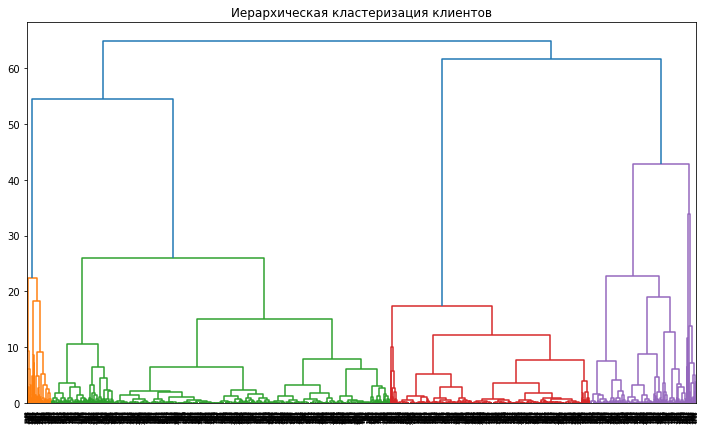

In [65]:
# Строим матрицу расстояний на стандартизованной матрице признаков
linked = linkage(x_sc, method = 'ward') 
plt.figure(figsize=(12, 7))  
dendrogram(linked, orientation='top')
plt.title('Иерархическая кластеризация клиентов')
plt.show() 

**Дендограмма разделила на 4 цвета связки. Также, если провести горизонтальную линию на высоте, соответствующей 70% всей высоты, то также получаем 4 пересечения. Оптимальное число кластеров = 4.**

### Прогнозирование кластеров клиентов на основе обучения модели кластеризации алгоритмом K-Means.

In [66]:
# задаём число кластеров, равное 4, и фиксируем значение random_state для воспроизводимости результата
km = KMeans(n_clusters=4, random_state=0) 
labels = km.fit_predict(x_sc) # применяем алгоритм к данным и формируем вектор кластеров 
# сохраняем метки кластера в поле нашего датасета
standardization['claster'] = labels
# выводим статистику по средним значениям признаков по кластеру
standardization.groupby('claster').agg('mean').transpose()

claster,0,1,2,3
order_count,1.00,2.04,1.35,1.06
count_mean,3.11,1.44,1.38,30.50
order_mean,788.24,692.89,4453.57,3239.92
price_mean,460.33,635.36,3694.00,127.50


In [67]:
# выведем ко-во клиентов по кластерам
standardization['claster'].value_counts()

0    1319
1     824
2     158
3     113
Name: claster, dtype: int64

#### Расчет  метрики силуэта

In [68]:
# посчитаем метрику силуэта для кластеризации
print('Silhouette_score: {:.2f}'.format(silhouette_score(x_sc, labels) ))

Silhouette_score: 0.57


**Метрика силуэта 0,57 говорит о хорошем разделении – большинство объектов ближе к своему кластеру, чем к соседним.**

### Графики распределения признаков в кластерах

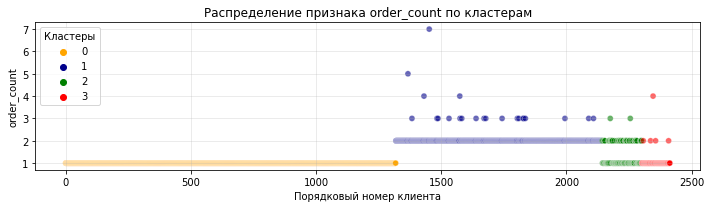

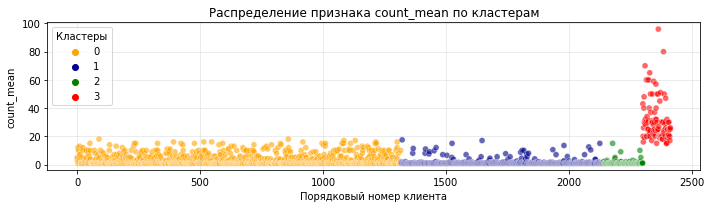

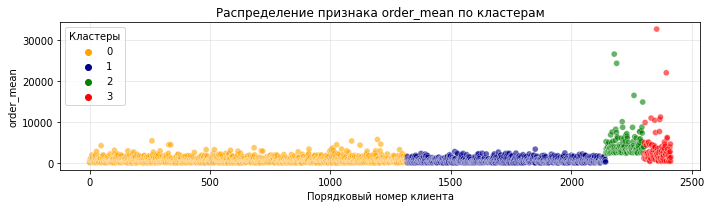

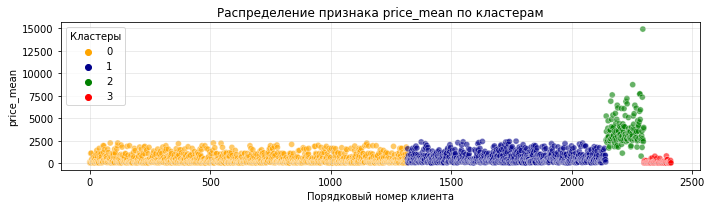

In [69]:
# создаем функцию для вывода графиков по каждому признаку
def plot_scatter_clusters(standardization, target_col='claster', 
                        palette={ 0: 'orange',  1: 'darkblue', 2: 'green',3: 'red',},
                        alpha=0.6,
                        x_label='Порядковый номер клиента',
                        legend_title='Кластеры',
                        grid_alpha=0.3, figsize=(10, 3)):
    
    # сортируем данные по кластерам для последовательного отображения
    data_sorted = standardization.sort_values(by=target_col)
    
    # Получаем уникальные кластеры в отсортированном порядке
    clusters = sorted(data_sorted[target_col].unique())
    
    # Создаем новую палитру только для существующих кластеров
    used_palette = {k: palette[k] for k in clusters}
    
    # Получаем признаки для отображения
    signs = data_sorted.drop(columns=[target_col]).columns
    
    for sign in signs:
        plt.figure(figsize=figsize)
        
        # Создаем scatterplot с явным порядком кластеров
        sns.scatterplot(
            x=range(len(data_sorted)),
            y=sign,
            hue=target_col,
            hue_order=clusters,
            palette=used_palette,
            data=data_sorted,
            alpha=alpha
        )
        
        plt.title(f'Распределение признака {sign} по кластерам')
        plt.xlabel(x_label)
        plt.ylabel(sign)
        plt.legend(title=legend_title)
        plt.grid(alpha=grid_alpha)
        plt.tight_layout()
        plt.show()
plot_scatter_clusters(standardization)

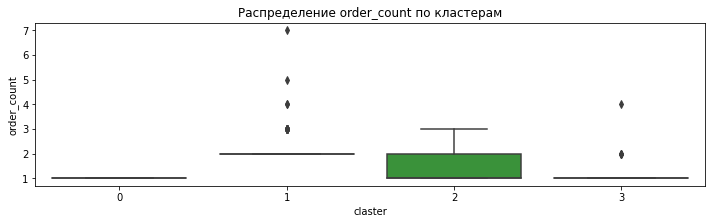

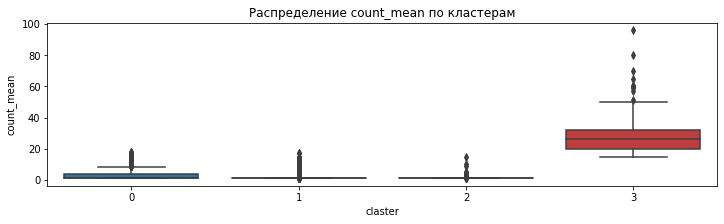

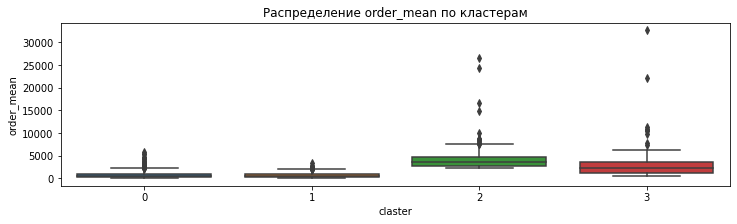

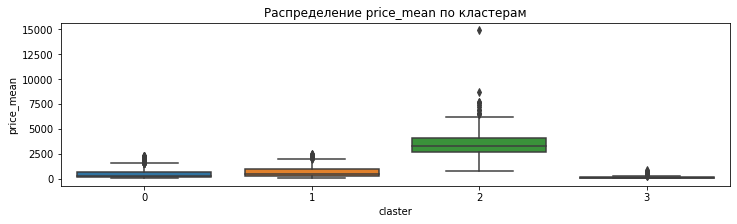

In [70]:
# цикл для построения диаграммы размаха по каждому признаку , по кластерам
for column in standardization:
    if column != 'claster':
        plt.figure(figsize=(12, 3))
        sns.boxplot(x='claster', y=column, data=standardization)
        plt.title(f'Распределение {column} по кластерам')
        plt.show()

**Выводы по сформированным кластерам:**

**1. Кластер 0: "Малоактивные покупатели с типичными чеками"**

- Самый массовый сегмент (44% всех клиентов)
- Частота заказов: 1 заказ (разовые покупки)
- Состав заказа: В среднем 3.11 товара в чеке
- Средний чек: 788 руб.
- Средняя цена товара: 460 руб.

**Основная масса разовых покупателей. Делают типичные заказы с несколькими товарами средней ценовой категории. Возможно, это случайные покупатели или те, кто пробует ассортимент.**

**2. Кластер 1: "Лояльные покупатели с концентрированными заказами"**

- Второй по величине сегмент (27% клиентов)
- Частота заказов: 2 заказа на клиента
- Состав заказа: Всего 1.44 товара в заказе (минимальный показатель)
- Средний чек: 693 руб. (самый низкий)
- Средняя цена товара: 635 руб. (выше чем в кластере 0)

**Клиенты делают несколько заказов, но покупают 1-2 более дорогих товара. Возможно, это целенаправленные покупки конкретных товаров или клиенты, чувствительные к цене.**


**3. Кластер 2: "Премиальные покупатели"**

- Небольшая группа (5% клиентов), но ценная
- Частота заказов: 1.35 заказа
- Состав заказа: 1.38 товара в заказе
- Средний чек: 4454 руб. (максимальный)
- Средняя цена товара: 3694 руб. 

**Делают 1-2 заказа, но покупают очень дорогие товары. Покупатели дорогих категорий.**

**4. Кластер 3: "Оптовые покупатели"**

- Самая маленькая группа (4% клиентов), но значимая
- Частота заказов: 1.06 заказа (фактически разовые)
- Состав заказа: 30.5 товара в заказе (аномально много)
- Средний чек: 3240 руб.
- Средняя цена товара: 127 руб. (минимальная)

**Покупают очень много дешевых товаров. Возможно, мелкий опт, розничные перепродавцы или закупки организаций.

### Проверка качества сегментации

**Убедимся в корректности проведенной кластеризации. Проверим два признака "средний прайс" и "среднее кол-во штук в заказе"  на определение статистической значимости разности между кластерами. Если хотя один признак будет отличаться во всех кластер, значит, кластеризация проведена корректно. Перед определением метода, которым будем проводить тест, рассмотрим распределение этих признаков по  кластерам.** 

In [71]:
# Список анализируемых метрик
metrics = ['order_count', 'count_mean', 'order_mean', 'price_mean']

# Проверяем нормальность для каждого кластера и каждой метрики
for cluster in sorted(standardization['claster'].unique()):
    print(f"\n Кластер {cluster}")
    cluster_data = standardization[standardization['claster'] == cluster]
    
    for metric in metrics:
        test = cluster_data[metric].dropna()
        stat, p_value = shapiro(test)
        
        print(f"\nМетрика: {metric}")
        print(f"  p-value: {p_value:.4f}")
        
        if p_value > 0.05:
            print("Распределение нормальное (p > 0.05)")
        else:
            print("Распределение НЕ нормальное (p ≤ 0.05)")


 Кластер 0

Метрика: order_count
  p-value: 1.0000
Распределение нормальное (p > 0.05)

Метрика: count_mean
  p-value: 0.0000
Распределение НЕ нормальное (p ≤ 0.05)

Метрика: order_mean
  p-value: 0.0000
Распределение НЕ нормальное (p ≤ 0.05)

Метрика: price_mean
  p-value: 0.0000
Распределение НЕ нормальное (p ≤ 0.05)

 Кластер 1

Метрика: order_count
  p-value: 0.0000
Распределение НЕ нормальное (p ≤ 0.05)

Метрика: count_mean
  p-value: 0.0000
Распределение НЕ нормальное (p ≤ 0.05)

Метрика: order_mean
  p-value: 0.0000
Распределение НЕ нормальное (p ≤ 0.05)

Метрика: price_mean
  p-value: 0.0000
Распределение НЕ нормальное (p ≤ 0.05)

 Кластер 2

Метрика: order_count
  p-value: 0.0000
Распределение НЕ нормальное (p ≤ 0.05)

Метрика: count_mean
  p-value: 0.0000
Распределение НЕ нормальное (p ≤ 0.05)

Метрика: order_mean
  p-value: 0.0000
Распределение НЕ нормальное (p ≤ 0.05)

Метрика: price_mean
  p-value: 0.0000
Распределение НЕ нормальное (p ≤ 0.05)

 Кластер 3

Метрика: order_

/opt/conda/lib/python3.9/site-packages/scipy/stats/_morestats.py:1797: UserWarning:

Input data for shapiro has range zero. The results may not be accurate.



**Распределение по заданным признакам не нормальное, для теста будем использовать метод Манна Уитни.**

#### Проверка гипотезы "Средний прайс на товар в сегментах покупателей отличается". 

Формулировка гипотезы:

Н0: Средний прайс на товар в сегментах покупателей не различаются.

Н1: Средний прайс на товар в сегментах различается.

Проверку гипотезы проведем методом Тьюки , так как у нас сегментов больше 2-ух.

Установим уровень статистической значимости , скорректированное с учетом множественной поправки методом Бонферрони. 

In [72]:
# cравниваемые кластеры
clusters = [0, 1, 2, 3]

# устанавливаем уровень стат. значимости с поправкой методом Бонферонни, для 6 пар сравнений
alpha = 0.05/6

# cписок для хранения результатов
results = []

# попарное сравнение всех кластеров
for i in range(len(clusters)):
    for j in range(i+1, len(clusters)):
        # получаем данные для пары кластеров
        data1 = standardization[standardization['claster'] == clusters[i]]['price_mean']
        data2 = standardization[standardization['claster'] == clusters[j]]['price_mean']
        
        # выполняем тест
        stat, p = stats.mannwhitneyu(data1, data2)
        
        # сохраняем результат
        results.append({
            'cluster1': clusters[i],
            'cluster2': clusters[j],
            'p-value': p,
            'significant': p < alpha
        })

# выводим результаты
for res in results:
    print(f"\nКластер {res['cluster1']} vs {res['cluster2']}:")
    print(f" p-value = {res['p-value']:.4f}")
    print(f" p-value < {alpha:.4f} ")
    print("Различия статистически значимы" if res['significant'] else "Нет значимых различий")


Кластер 0 vs 1:
 p-value = 0.0000
 p-value < 0.0083 
Различия статистически значимы

Кластер 0 vs 2:
 p-value = 0.0000
 p-value < 0.0083 
Различия статистически значимы

Кластер 0 vs 3:
 p-value = 0.0000
 p-value < 0.0083 
Различия статистически значимы

Кластер 1 vs 2:
 p-value = 0.0000
 p-value < 0.0083 
Различия статистически значимы

Кластер 1 vs 3:
 p-value = 0.0000
 p-value < 0.0083 
Различия статистически значимы

Кластер 2 vs 3:
 p-value = 0.0000
 p-value < 0.0083 
Различия статистически значимы


**Результат теста:**

Все сравнения имеют статистически значимые различия. Отвергаем нулевую гипотезу. Есть основания предполагать, что средние прайсы во всех кластерах отличаются друг от друга.



#### Проверка гипотезы "Среднее кол-во штук в заказах в сегментах покупателей отличается". 

Формулировка гипотезы:

Н0: Среднее кол-во штук в заказах в сегментах покупателей не различаются.

Н1: Среднее кол-во штук в заказах  в сегментах различается.

Проверку гипотезы проведем также методом Тьюки .

Установим уровень статистической значимости 5% с поправкой Бонферрони для 6 пар сравнений.

In [73]:
# Сравниваемые кластеры (0-3)
clusters = [0, 1, 2, 3]

# устанавливаем уровень стат. значимости с поправкой методом Бонферонни, для 6 пар сравнений
alpha = 0.05/6

# Список для хранения результатов
results = []

# Попарное сравнение всех кластеров
for i in range(len(clusters)):
    for j in range(i+1, len(clusters)):
        # Получаем данные для пары кластеров
        data1 = standardization[standardization['claster'] == clusters[i]]['count_mean']
        data2 = standardization[standardization['claster'] == clusters[j]]['count_mean']
        
        # Выполняем тест
        stat, p = stats.mannwhitneyu(data1, data2)
        
        # Сохраняем результат
        results.append({
            'cluster1': clusters[i],
            'cluster2': clusters[j],
            'p-value': p,
            'significant': p < alpha
        })

# Выводим результаты
for res in results:
    print(f"\nКластер {res['cluster1']} vs {res['cluster2']}:")
    print(f" p-value = {res['p-value']:.4f}")
    print(f" p-value < {alpha:.4f} ")
    print("Различия статистически значимы" if res['significant'] else "Нет значимых различий")


Кластер 0 vs 1:
 p-value = 0.0000
 p-value < 0.0083 
Различия статистически значимы

Кластер 0 vs 2:
 p-value = 0.0000
 p-value < 0.0083 
Различия статистически значимы

Кластер 0 vs 3:
 p-value = 0.0000
 p-value < 0.0083 
Различия статистически значимы

Кластер 1 vs 2:
 p-value = 0.9827
 p-value < 0.0083 
Нет значимых различий

Кластер 1 vs 3:
 p-value = 0.0000
 p-value < 0.0083 
Различия статистически значимы

Кластер 2 vs 3:
 p-value = 0.0000
 p-value < 0.0083 
Различия статистически значимы


**Результат теста:**

Все кластеры, кроме 1 и 2, имеют статистически значимые различия . 

Кластеры 1 и 2 не имеют статистически значимых различий.

По итогам проведения теста нулевую гипотезу не получилось отвергнуть. Значит, нет оснований предполагать, что среднее кол-во штук в заказах во всех сегментах различается.

## Построение "профиля потребления" в сегментах пользователей.

### Кластер 0. Топ-N самых покупаемых категорий и товаров, сезонные предпочтения

In [74]:
# добавляем в таблицу с пользователями номер кластера
customers_filter['claster'] = standardization['claster']

# создаем очищенный датасет с транзакциями от пользователей , попавших в аномальный список, добавляем кластеры
data_filter = data.merge(customers_filter[['customer_id','claster']],
                         left_on='customer_id', right_on='customer_id', how='inner')
data_filter.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5317 entries, 0 to 5316
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         5317 non-null   datetime64[ns]
 1   customer_id  5317 non-null   object        
 2   order_id     5317 non-null   int64         
 3   product      5317 non-null   object        
 4   quantity     5317 non-null   int64         
 5   price        5317 non-null   float64       
 6   revenue      5317 non-null   float64       
 7   year_month   5317 non-null   period[M]     
 8   category     5317 non-null   object        
 9   claster      5317 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(2), object(3), period[M](1)
memory usage: 436.2+ KB


In [75]:
# формируем таблицу с покупками по категориям по кластеру 0

categories_claster_0 = data_filter.query('claster==0').groupby('category').agg({'revenue':'sum','quantity':'sum'})
categories_claster_0 = categories_claster_0.sort_values(by='revenue',ascending=False).reset_index()
categories_claster_0.columns = ['category','sales','count']
# добавляем долю категории в общих покупкам кластера
categories_claster_0['part'] = categories_claster_0['sales']/categories_claster_0['sales'].sum()
# добавляем кумулятивную долю 
categories_claster_0['cumulative_part'] = categories_claster_0['part'].cumsum()
categories_claster_0

,category,sales,count,part,cumulative_part
0,"Цветы, растения",195896.50,1104,0.19,0.19
1,"Сушилки, гладильные доски",179541.50,256,0.17,0.36
2,Оборудование для хоз. работ,150389.00,148,0.14,0.51
3,Товары для кухни,128309.00,568,0.12,0.63
4,"Мебель, интерьер, фурнитура",63066.00,117,0.06,0.69
5,"Сантехника, все для ванной комнаты",61021.00,100,0.06,0.75
6,Вешалки и хранение вещей,60159.50,217,0.06,0.81
7,"Рассада, саженцы",58749.00,578,0.06,0.86
8,"Хоз.товары, для уборки",50707.00,177,0.05,0.91
9,"Постельное белье, и текстиль",38360.00,74,0.04,0.95


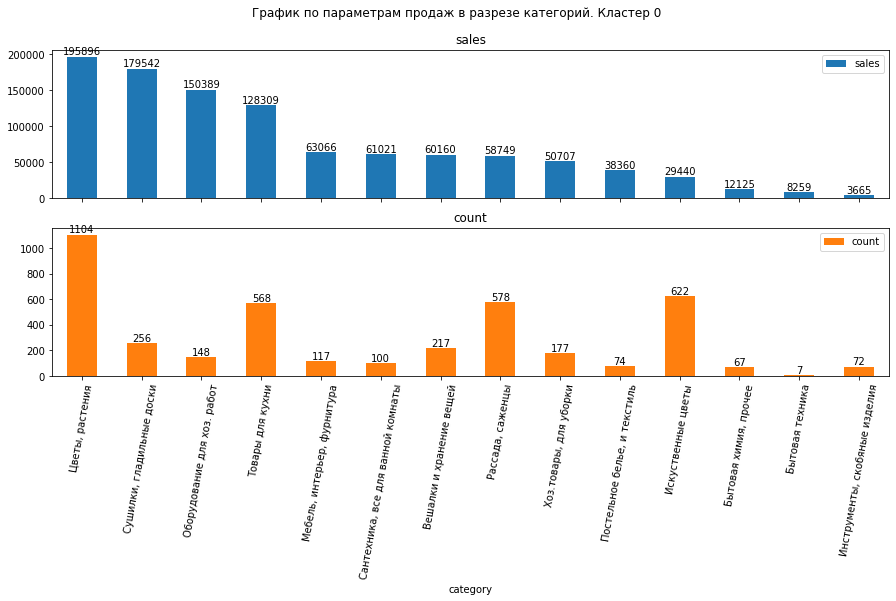

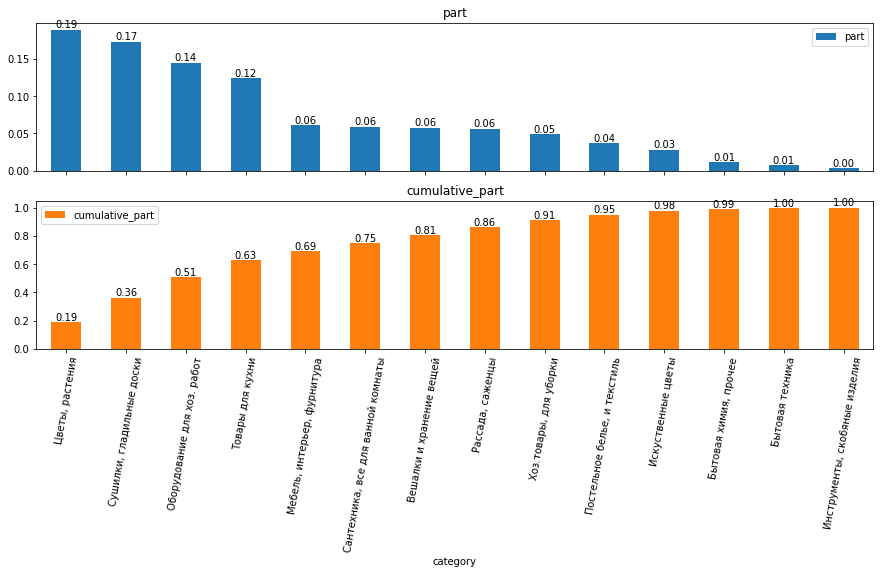

In [76]:
# строим график продаж по категориям кластера 0

# выводим первую часть
ax1= (categories_claster_0.drop(['part','cumulative_part'],axis=1)
     .plot(kind='bar',x = 'category', subplots=True,
      figsize = (15,6),
      title = 'График по параметрам продаж в разрезе категорий. Кластер 0')
)

# добавление аннотаций 
for i, (category, sales) in enumerate(zip(categories_claster_0['category'],categories_claster_0['sales'])):
    ax1[0].annotate(f'{sales:.0f}', xy=(i, sales), ha='center', va='bottom')

for i, (category, count) in enumerate(zip(categories_claster_0['category'],categories_claster_0['count'])):
    ax1[1].annotate(f'{count:.0f}', xy=(i, count), ha='center', va='bottom')
plt.xticks(rotation=80)
plt.show()

# выводим вторую часть
ax2= (categories_claster_0.drop(['sales','count'],axis=1)
     .plot(kind='bar',x = 'category', subplots=True,
      figsize = (15,6))
)

# добавление аннотаций 
for i, (category, count) in enumerate(zip(categories_claster_0['category'],categories_claster_0['part'])):
    ax2[0].annotate(f'{count:.2f}', xy=(i, count), ha='center', va='bottom')
    
for i, (category, count) in enumerate(zip(categories_claster_0['category'],categories_claster_0['cumulative_part'])):
    ax2[1].annotate(f'{count:.2f}', xy=(i, count), ha='center', va='bottom')
plt.xticks(rotation=80)    
plt.show()

In [77]:
# формируем таблицу с покупками по категориям по месяцам по кластеру 0 
year_claster_0 = (data_filter.query('claster==0').groupby(['year_month','category'])
                  .agg({'revenue':'sum','quantity':'sum'}).reset_index())
year_claster_0.columns = ['period','category','sales','count']

In [78]:
# меняем тип данных для формирования графика
year_claster_0['period'] = year_claster_0['period'].astype(str)

# строим график продаж категорий по выручке
fig = px.bar(year_claster_0,
             x='period',
             y='sales',
             color='category',
             color_discrete_sequence=px.colors.qualitative.Light24,
             text='sales'
            )

fig.update_layout(
    title={'text': 'Выручка с категорий по месяцам. Кластер 0', 'font': {'size': 15}},
    title_x=0.5,
    xaxis_title='Период',
    yaxis_title='Выручка',
    yaxis={'categoryorder': 'total ascending'},
    template="plotly_white",
    
    # Настройки легенды:
    legend=dict(
        font=dict(size=10),  # Размер шрифта
        orientation='h',  # Горизонтальное расположение
        yanchor='bottom',  # Якорь снизу
        y=-0.5,  # Смещение ниже графика (отрицательное значение)
        xanchor='center',  # Выравнивание по центру
        x=0.5  # Позиция по горизонтали
    )
)

# Форматирование текста на столбцах
fig.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside',
    textfont_size=10  # Размер шрифта значений на столбцах
)

fig.show()

# строим график продаж категорий по штукам
fig = px.bar(year_claster_0,
             x='period',
             y='count',
             color='category',
             color_discrete_sequence=px.colors.qualitative.Light24,
             text='count'  
            )

fig.update_layout(
    title={'text': 'Продажи категорий в штуках по месяцам. Кластер 0', 'font': {'size': 15}},
    title_x=0.5,
    xaxis_title='Период',
    yaxis_title='Продажи, шт.',
    yaxis={'categoryorder': 'total ascending'},
    template="plotly_white",
    
    # Настройки легенды:
    legend=dict(
        font=dict(size=10),  # Размер шрифта
        orientation='h',  # Горизонтальное расположение
        yanchor='bottom',  # Якорь снизу
        y=-0.5,  # Смещение ниже графика (отрицательное значение)
        xanchor='center',  # Выравнивание по центру
        x=0.5  # Позиция по горизонтали
    )
)

# Форматирование текста на столбцах
fig.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside',
    textfont_size=10  # Размер шрифта значений на столбцах
)

fig.show()

In [79]:
# топ товары по кол-ву продаж
(data_filter.query('claster==0').pivot_table(index='product',values='quantity',aggfunc='sum')
 .sort_values(by='quantity', ascending=False).head(10))

,quantity
product,
цветок искусственный гвоздика пластиковая одиночная в ассортименте 50 см,46
пеларгония зональная диам. 12 см сиреневый полумахровый,39
сумка-тележка 2-х колесная gimi argo синяя,38
пеларгония зональная диам. 12 см красная махровая,37
пеларгония розебудная red pandora укорененный черенок,37
пеларгония розебудная prins nikolai укорененный черенок,33
пеларгония розебудная margaretha укорененный черенок,29
муляж персики мини полиуретан d-6 см,27
"однолетнее растение петуния махровая в кассете 4 шт, россия",26


**Наблюдения по кластеру 0:**

1. Категории, которые принесли  80% прибыли:

- Цветы, растения 195 896 руб.
- Сушилки, гладильные доски 179 541 руб.
- Оборудование для хоз. работ 150 389 руб.
- Товары для кухни 128 309 руб.
- Мебель, интерьер, фурнитура	  63 066 руб.
- Сантехника, все для ванной комнаты 61 021 руб.
- Вешалки и хранение вещей 60 159 руб.

2. Больше всего было продано   цветы 1104 шт., всё для кухни 568 шт. , рассада 578 шт. , искуственные цветы 622 шт.

3. В динамике продаж по месяцам наблюдается увеличение продаж сезонного товара: рассады и саженцев. Но общая динамика не зависит от этой категории сезонных товаров, весеннего всплеска продаж не наблюдается. С ноября 2019 в данный кластер не попало ни одного покупателя, соответсвенно можно сделать вывод, что профиль потребления начал смещаться в сторону кластеров 1,2 и 3.




### Кластер 1. Топ-N самых покупаемых категорий и товаров, сезонные предпочтения

In [80]:
# формируем таблицу с покупками по категориям по кластеру 1

categories_claster_1 = data_filter.query('claster==1').groupby('category').agg({'revenue':'sum','quantity':'sum'})
categories_claster_1 = categories_claster_1.sort_values(by='revenue',ascending=False).reset_index()
categories_claster_1.columns = ['category','sales','count']
# добавляем долю категории в общих покупкам кластера
categories_claster_1['part'] = categories_claster_1['sales']/categories_claster_1['sales'].sum()
# добавляем кумулятивную долю
categories_claster_1['cumulative_part'] = categories_claster_1['part'].cumsum()
categories_claster_1

,category,sales,count,part,cumulative_part
0,"Сушилки, гладильные доски",288007.67,268,0.25,0.25
1,Оборудование для хоз. работ,267765.75,166,0.23,0.48
2,"Цветы, растения",126921.33,633,0.11,0.59
3,"Мебель, интерьер, фурнитура",80541.50,96,0.07,0.66
4,Товары для кухни,76601.00,229,0.07,0.72
5,"Сантехника, все для ванной комнаты",74856.00,95,0.06,0.79
6,"Хоз.товары, для уборки",71397.50,115,0.06,0.85
7,"Постельное белье, и текстиль",42625.00,48,0.04,0.89
8,Вешалки и хранение вещей,41661.50,113,0.04,0.92
9,"Рассада, саженцы",41053.50,496,0.04,0.96


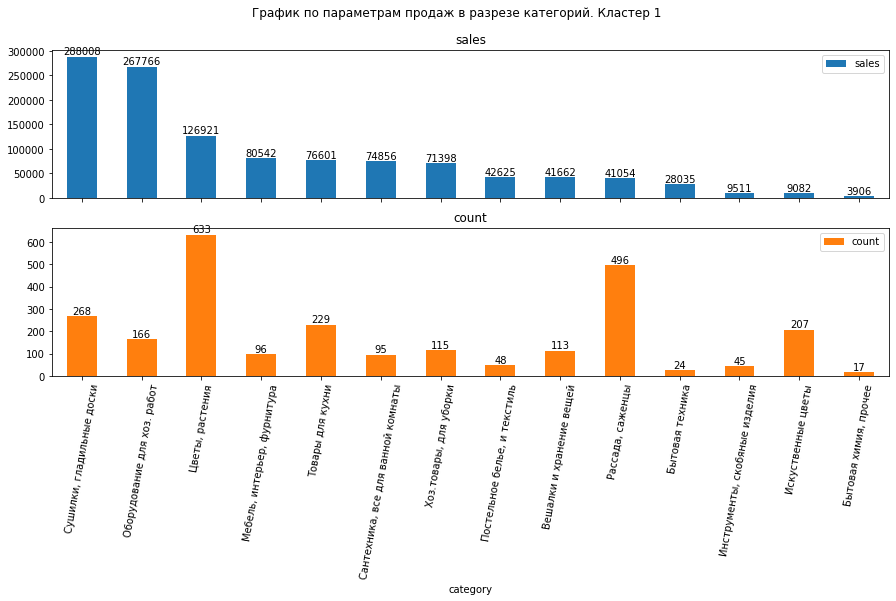

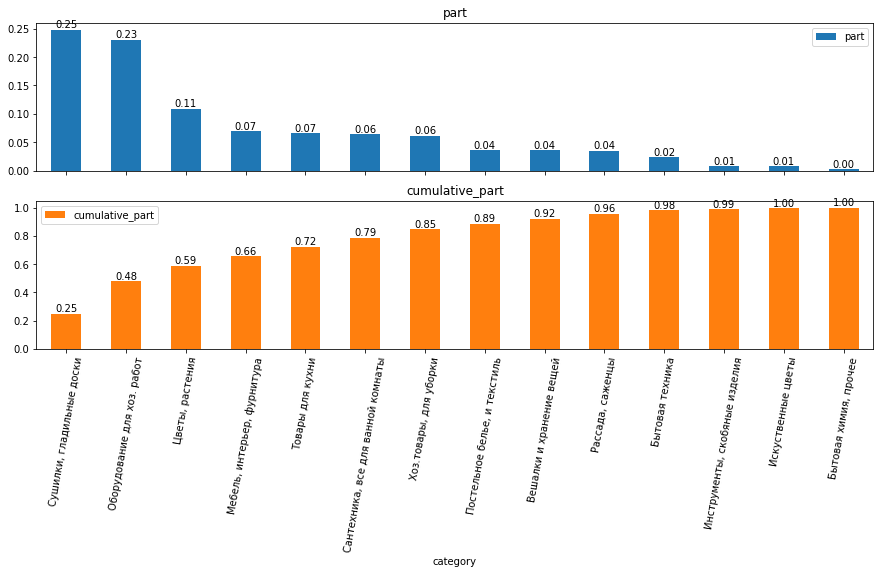

In [81]:
# строим график продаж по категориям кластера 1

# выводим первую часть
ax1= (categories_claster_1.drop(['part','cumulative_part'],axis=1)
     .plot(kind='bar',x = 'category', subplots=True,
      figsize = (15,6),
      title = 'График по параметрам продаж в разрезе категорий. Кластер 1')
)

# добавление аннотаций 
for i, (category, sales) in enumerate(zip(categories_claster_1['category'],categories_claster_1['sales'])):
    ax1[0].annotate(f'{sales:.0f}', xy=(i, sales), ha='center', va='bottom')

for i, (category, count) in enumerate(zip(categories_claster_1['category'],categories_claster_1['count'])):
    ax1[1].annotate(f'{count:.0f}', xy=(i, count), ha='center', va='bottom')
plt.xticks(rotation=80)
plt.show()

# выводим вторую часть
ax2= (categories_claster_1.drop(['sales','count'],axis=1)
     .plot(kind='bar',x = 'category', subplots=True,
      figsize = (15,6))
)

# добавление аннотаций 
for i, (category, count) in enumerate(zip(categories_claster_1['category'],categories_claster_1['part'])):
    ax2[0].annotate(f'{count:.2f}', xy=(i, count), ha='center', va='bottom')
    
for i, (category, count) in enumerate(zip(categories_claster_1['category'],categories_claster_1['cumulative_part'])):
    ax2[1].annotate(f'{count:.2f}', xy=(i, count), ha='center', va='bottom')
plt.xticks(rotation=80)    
plt.show()

In [82]:
# формируем таблицу с покупками по категориям по месяцам по кластеру 1 
year_claster_1 = (data_filter.query('claster==1').groupby(['year_month','category'])
                  .agg({'revenue':'sum','quantity':'sum'}).reset_index())
year_claster_1.columns = ['period','category','sales','count']

In [83]:
# меняем тип данных для формирования графика
year_claster_1['period'] = year_claster_1['period'].astype(str)

# строим график продаж категорий по выручке
fig = px.bar(year_claster_1,
             x='period',
             y='sales',
             color='category',
             color_discrete_sequence=px.colors.qualitative.Light24,
             text='sales'
            )

fig.update_layout(
    title={'text': 'Выручка с категорий по месяцам. Кластер 1', 'font': {'size': 15}},
    title_x=0.5,
    xaxis_title='Период',
    yaxis_title='Выручка',
    yaxis={'categoryorder': 'total ascending'},
    template="plotly_white",
    
    # Настройки легенды:
    legend=dict(
        font=dict(size=10),  # Размер шрифта
        orientation='h',  # Горизонтальное расположение
        yanchor='bottom',  # Якорь снизу
        y=-0.5,  # Смещение ниже графика (отрицательное значение)
        xanchor='center',  # Выравнивание по центру
        x=0.5  # Позиция по горизонтали
    )
)

# Форматирование текста на столбцах
fig.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside',
    textfont_size=10  # Размер шрифта значений на столбцах
)

fig.show()

# строим график продаж категорий по штукам
fig = px.bar(year_claster_1,
             x='period',
             y='count',
             color='category',
             color_discrete_sequence=px.colors.qualitative.Light24,
             text='count'  
            )

fig.update_layout(
    title={'text': 'Продажи категорий в штуках по месяцам. Кластер 1', 'font': {'size': 15}},
    title_x=0.5,
    xaxis_title='Период',
    yaxis_title='Продажи, шт.',
    yaxis={'categoryorder': 'total ascending'},
    template="plotly_white",
    
    # Настройки легенды:
    legend=dict(
        font=dict(size=10),  # Размер шрифта
        orientation='h',  # Горизонтальное расположение
        yanchor='bottom',  # Якорь снизу
        y=-0.5,  # Смещение ниже графика (отрицательное значение)
        xanchor='center',  # Выравнивание по центру
        x=0.5  # Позиция по горизонтали
    )
)

# Форматирование текста на столбцах
fig.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside',
    textfont_size=10  # Размер шрифта значений на столбцах
)

fig.show()

**Наблюдения по кластеру 1:**

1. Категории, которые принесли  80% прибыли:

- Сушилки, гладильные доски 288 007 руб.
- Оборудование для хоз. работ 267 765 руб.
- Цветы, растения 126 921 руб.
- Мебель, интерьер, фурнитура 80 541 руб.
- Товары для кухни 76 601 руб.
- Сантехника, все для ванной комнаты 74 856 руб.

2. Больше всего было продано цветов 633  шт. и рассады 496 шт. 

3. В апреле и мае наблюдается всплеск сезонных продаж сезонных товаров (рассады) в штуках. Но  в выручке в период с апреля по октябрь происходит падение продаж. Однако важно отметить, что с ноября 2019 года значительный рост продаж с самой большой выручкой. Больше всего выручки в этот период принесли категории: гладильные доски/сушки, сумки тележки /стремянки и инструменты.




### Кластер 2. Топ-N самых покупаемых категорий и товаров, сезонные предпочтения

In [84]:
# формируем таблицу с покупками по категориям по кластеру 2

categories_claster_2 = data_filter.query('claster==2').groupby('category').agg({'revenue':'sum','quantity':'sum'})
categories_claster_2 = categories_claster_2.sort_values(by='revenue',ascending=False).reset_index()
categories_claster_2.columns = ['category','sales','count']
# добавляем долю категории в общих покупкам кластера
categories_claster_2['part'] = categories_claster_2['sales']/categories_claster_2['sales'].sum()
# добавляем кумулятивную долю
categories_claster_2['cumulative_part'] = categories_claster_2['part'].cumsum()
categories_claster_2

,category,sales,count,part,cumulative_part
0,Оборудование для хоз. работ,417875.50,95,0.45,0.45
1,"Сушилки, гладильные доски",166877.00,51,0.18,0.63
2,"Хоз.товары, для уборки",108991.00,25,0.12,0.74
3,"Постельное белье, и текстиль",100875.00,57,0.11,0.85
4,"Сантехника, все для ванной комнаты",57986.00,21,0.06,0.91
5,"Мебель, интерьер, фурнитура",42391.00,16,0.05,0.96
6,"Цветы, растения",27725.00,15,0.03,0.99
7,Товары для кухни,5619.00,8,0.01,0.99
8,"Инструменты, скобяные изделия",5480.00,3,0.01,1.00
9,"Рассада, саженцы",788.00,6,0.00,1.00


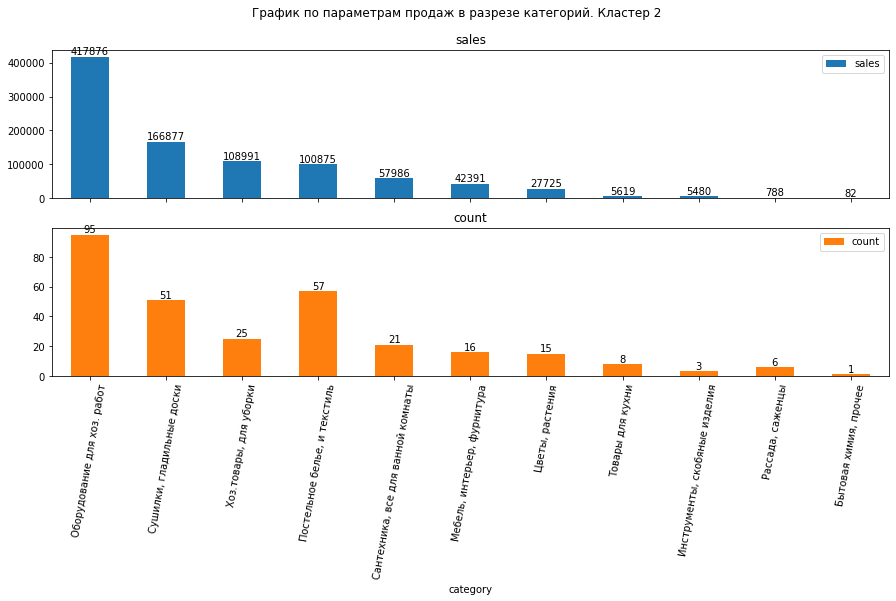

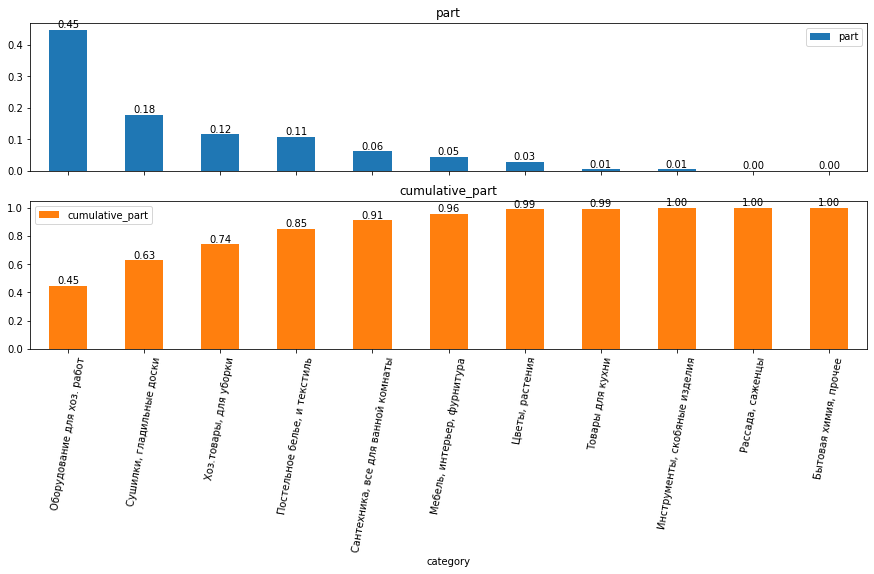

In [85]:
# строим график продаж по категориям кластера 2

# выводим первую часть
ax1= (categories_claster_2.drop(['part','cumulative_part'],axis=1)
     .plot(kind='bar',x = 'category', subplots=True,
      figsize = (15,6),
      title = 'График по параметрам продаж в разрезе категорий. Кластер 2')
)

# добавление аннотаций 
for i, (category, sales) in enumerate(zip(categories_claster_2['category'],categories_claster_2['sales'])):
    ax1[0].annotate(f'{sales:.0f}', xy=(i, sales), ha='center', va='bottom')

for i, (category, count) in enumerate(zip(categories_claster_2['category'],categories_claster_2['count'])):
    ax1[1].annotate(f'{count:.0f}', xy=(i, count), ha='center', va='bottom')
plt.xticks(rotation=80)
plt.show()

# выводим вторую часть
ax2= (categories_claster_2.drop(['sales','count'],axis=1)
     .plot(kind='bar',x = 'category', subplots=True,
      figsize = (15,6))
)

# добавление аннотаций 
for i, (category, count) in enumerate(zip(categories_claster_2['category'],categories_claster_2['part'])):
    ax2[0].annotate(f'{count:.2f}', xy=(i, count), ha='center', va='bottom')
    
for i, (category, count) in enumerate(zip(categories_claster_2['category'],categories_claster_2['cumulative_part'])):
    ax2[1].annotate(f'{count:.2f}', xy=(i, count), ha='center', va='bottom')
plt.xticks(rotation=80)    
plt.show()

In [86]:
# формируем таблицу с покупками по категориям по месяцам по кластеру 2 
year_claster_2 = (data_filter.query('claster==2').groupby(['year_month','category'])
                  .agg({'revenue':'sum','quantity':'sum'}).reset_index())
year_claster_2.columns = ['period','category','sales','count']

In [87]:
# меняем тип данных для формирования графика
year_claster_2['period'] = year_claster_2['period'].astype(str)

# строим график продаж категорий по выручке
fig = px.bar(year_claster_2,
             x='period',
             y='sales',
             color='category',
             color_discrete_sequence=px.colors.qualitative.Light24,
             text='sales'
            )

fig.update_layout(
    title={'text': 'Выручка с категорий по месяцам. Кластер 2', 'font': {'size': 15}},
    title_x=0.5,
    xaxis_title='Период',
    yaxis_title='Выручка',
    yaxis={'categoryorder': 'total ascending'},
    template="plotly_white",
    
    # Настройки легенды:
    legend=dict(
        font=dict(size=10),  # Размер шрифта
        orientation='h',  # Горизонтальное расположение
        yanchor='bottom',  # Якорь снизу
        y=-0.5,  # Смещение ниже графика (отрицательное значение)
        xanchor='center',  # Выравнивание по центру
        x=0.5  # Позиция по горизонтали
    )
)

# Форматирование текста на столбцах
fig.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside',
    textfont_size=10  # Размер шрифта значений на столбцах
)

fig.show()

# строим график продаж категорий по штукам
fig = px.bar(year_claster_2,
             x='period',
             y='count',
             color='category',
             color_discrete_sequence=px.colors.qualitative.Light24,
             text='count'  
            )

fig.update_layout(
    title={'text': 'Продажи категорий в штуках по месяцам. Кластер 2', 'font': {'size': 15}},
    title_x=0.5,
    xaxis_title='Период',
    yaxis_title='Продажи, шт.',
    yaxis={'categoryorder': 'total ascending'},
    template="plotly_white",
    
    # Настройки легенды:
    legend=dict(
        font=dict(size=10),  # Размер шрифта
        orientation='h',  # Горизонтальное расположение
        yanchor='bottom',  # Якорь снизу
        y=-0.5,  # Смещение ниже графика (отрицательное значение)
        xanchor='center',  # Выравнивание по центру
        x=0.5  # Позиция по горизонтали
    )
)

# Форматирование текста на столбцах
fig.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside',
    textfont_size=10  # Размер шрифта значений на столбцах
)

fig.show()

In [88]:
# топ товары по кол-ву продаж
(data_filter.query('claster==2').pivot_table(index='product',values='quantity',aggfunc='sum')
 .sort_values(by='quantity', ascending=False).head(10))

,quantity
product,
простынь вафельная 200х180 см wellness rw180-01 100% хлопок,30
чехол для гладильной доски attribute metal 140х60 см abm106,10
скатерть круглая d-175 см 50% полиэстер 50% хлопок белая wellness mld-187-эстель*01,10
скатерть 180 см wellness wtd180-лион*01 100% полиэстер,8
сумка-тележка 3-х колесная gimi tris floral синяя,6
"сумка-тележка twin стальной каркас 56 л синяя, gimi",5
мусорный контейнер hailo bigbin swing 45 0845-010 45 л хром,5
"урна уличная ""гео"", hobbyka/хоббика, 59*37,5см, сталь",5
спатифиллум свит лауретта d-21 см h-95 см,5


**Наблюдения по кластеру 2:**

1. Категории, которые принесли  85% прибыли:

- Оборудование для хоз. работ 417 875 руб.
- Сушилки, гладильные доски  166 877 руб.
- Хоз.товары, для уборки 108 991 руб.
- Постельное белье, и текстиль 100 875 руб.

2. Больше всего было продано оборудование для хоз. работ, то тележки и стремянки  95  шт., постельное белье 57 шт. и сушилки/гладильные доски 51 шт. 

3. Категория постельное белье имеет сезонность: объемные продажи в январе и июне.


### Кластер 3. Топ-N самых покупаемых категорий и товаров, сезонные предпочтения

In [89]:
# формируем таблицу с покупками по категориям по кластеру 3

categories_claster_3 = data_filter.query('claster==3').groupby('category').agg({'revenue':'sum','quantity':'sum'})
categories_claster_3 = categories_claster_3.sort_values(by='revenue',ascending=False).reset_index()
categories_claster_3.columns = ['category','sales','count']
# добавляем долю категории в общих покупкам кластера
categories_claster_3['part'] = categories_claster_3['sales']/categories_claster_3['sales'].sum()
# добавляем кумулятивную долю
categories_claster_3['cumulative_part'] = categories_claster_3['part'].cumsum()
categories_claster_3

,category,sales,count,part,cumulative_part
0,"Цветы, растения",66692.00,424,0.16,0.16
1,Вешалки и хранение вещей,59576.00,472,0.15,0.31
2,"Рассада, саженцы",54755.00,752,0.14,0.45
3,Иcкуственные цветы,41456.00,850,0.10,0.55
4,Товары для кухни,40467.00,402,0.10,0.65
5,"Постельное белье, и текстиль",34897.00,26,0.09,0.74
6,"Хоз.товары, для уборки",33347.00,362,0.08,0.82
7,Оборудование для хоз. работ,32718.00,57,0.08,0.90
8,"Мебель, интерьер, фурнитура",19695.00,109,0.05,0.95
9,"Сантехника, все для ванной комнаты",8689.00,95,0.02,0.97


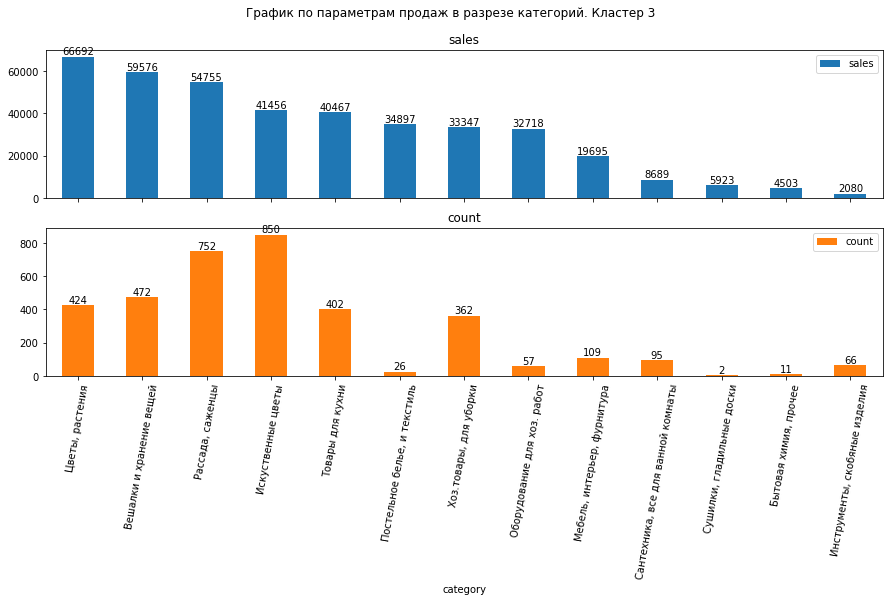

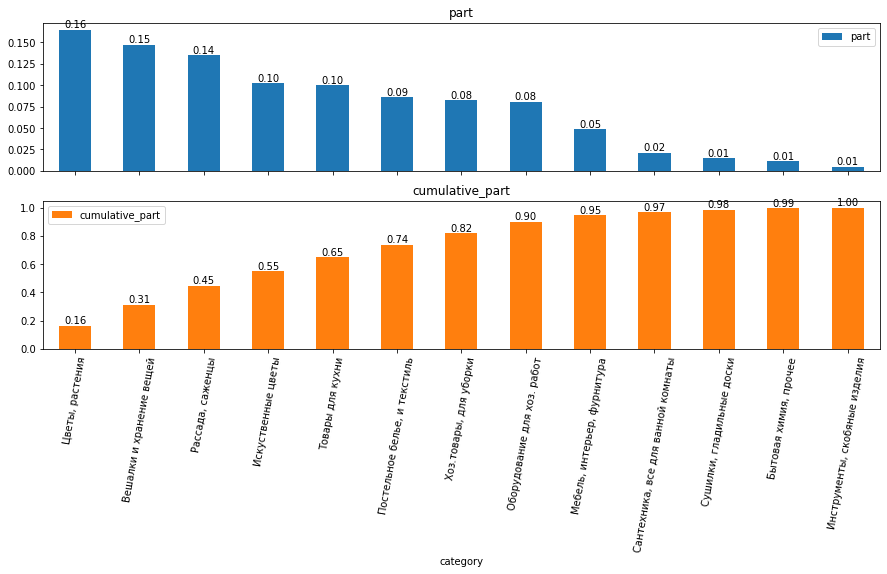

In [90]:
# строим график продаж по категориям кластера 3

# выводим первую часть
ax1= (categories_claster_3.drop(['part','cumulative_part'],axis=1)
     .plot(kind='bar',x = 'category', subplots=True,
      figsize = (15,6),
      title = 'График по параметрам продаж в разрезе категорий. Кластер 3')
)

# добавление аннотаций 
for i, (category, sales) in enumerate(zip(categories_claster_3['category'],categories_claster_3['sales'])):
    ax1[0].annotate(f'{sales:.0f}', xy=(i, sales), ha='center', va='bottom')

for i, (category, count) in enumerate(zip(categories_claster_3['category'],categories_claster_3['count'])):
    ax1[1].annotate(f'{count:.0f}', xy=(i, count), ha='center', va='bottom')
plt.xticks(rotation=80)
plt.show()

# выводим вторую часть
ax2= (categories_claster_3.drop(['sales','count'],axis=1)
     .plot(kind='bar',x = 'category', subplots=True,
      figsize = (15,6))
)

# добавление аннотаций 
for i, (category, count) in enumerate(zip(categories_claster_3['category'],categories_claster_3['part'])):
    ax2[0].annotate(f'{count:.2f}', xy=(i, count), ha='center', va='bottom')
    
for i, (category, count) in enumerate(zip(categories_claster_3['category'],categories_claster_3['cumulative_part'])):
    ax2[1].annotate(f'{count:.2f}', xy=(i, count), ha='center', va='bottom')
plt.xticks(rotation=80)    
plt.show()

In [91]:
# формируем таблицу с покупками по категориям по месяцам по кластеру 2 
year_claster_3 = (data_filter.query('claster==3').groupby(['year_month','category'])
                  .agg({'revenue':'sum','quantity':'sum'}).reset_index())
year_claster_3.columns = ['period','category','sales','count']

In [92]:
# меняем тип данных для формирования графика
year_claster_3['period'] = year_claster_3['period'].astype(str)

# строим график продаж категорий по выручке
fig = px.bar(year_claster_3,
             x='period',
             y='sales',
             color='category',
             color_discrete_sequence=px.colors.qualitative.Light24,
             text='sales'
            )

fig.update_layout(
    title={'text': 'Выручка с категорий по месяцам. Кластер 3', 'font': {'size': 15}},
    title_x=0.5,
    xaxis_title='Период',
    yaxis_title='Выручка',
    yaxis={'categoryorder': 'total ascending'},
    template="plotly_white",
    
    # Настройки легенды:
    legend=dict(
        font=dict(size=10),  # Размер шрифта
        orientation='h',  # Горизонтальное расположение
        yanchor='bottom',  # Якорь снизу
        y=-0.5,  # Смещение ниже графика (отрицательное значение)
        xanchor='center',  # Выравнивание по центру
        x=0.5  # Позиция по горизонтали
    )
)

# Форматирование текста на столбцах
fig.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside',
    textfont_size=10  # Размер шрифта значений на столбцах
)

fig.show()

# строим график продаж категорий по штукам
fig = px.bar(year_claster_3,
             x='period',
             y='count',
             color='category',
             color_discrete_sequence=px.colors.qualitative.Light24,
             text='count'  
            )

fig.update_layout(
    title={'text': 'Продажи категорий в штуках по месяцам. Кластер 3', 'font': {'size': 15}},
    title_x=0.5,
    xaxis_title='Период',
    yaxis_title='Продажи, шт.',
    yaxis={'categoryorder': 'total ascending'},
    template="plotly_white",
    
    # Настройки легенды:
    legend=dict(
        font=dict(size=10),  # Размер шрифта
        orientation='h',  # Горизонтальное расположение
        yanchor='bottom',  # Якорь снизу
        y=-0.5,  # Смещение ниже графика (отрицательное значение)
        xanchor='center',  # Выравнивание по центру
        x=0.5  # Позиция по горизонтали
    )
)

# Форматирование текста на столбцах
fig.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside',
    textfont_size=10  # Размер шрифта значений на столбцах
)

fig.show()

In [93]:
categories_claster_3

,category,sales,count,part,cumulative_part
0,"Цветы, растения",66692.00,424,0.16,0.16
1,Вешалки и хранение вещей,59576.00,472,0.15,0.31
2,"Рассада, саженцы",54755.00,752,0.14,0.45
3,Иcкуственные цветы,41456.00,850,0.10,0.55
4,Товары для кухни,40467.00,402,0.10,0.65
5,"Постельное белье, и текстиль",34897.00,26,0.09,0.74
6,"Хоз.товары, для уборки",33347.00,362,0.08,0.82
7,Оборудование для хоз. работ,32718.00,57,0.08,0.90
8,"Мебель, интерьер, фурнитура",19695.00,109,0.05,0.95
9,"Сантехника, все для ванной комнаты",8689.00,95,0.02,0.97


**Наблюдения по кластеру 3:**

1. Категории, которые принесли  80% прибыли:

- Цветы, растения  66 692 руб.
- Вешалки и хранение вещей 59 576 руб.
- Рассада, саженцы  54 755 руб.
- Иcкуственные цветы 41 456 руб.
- Товары для кухни 40 467 руб.
- Постельное белье, и текстиль	34 897 руб.
- Хоз.товары, для уборки  33 347 руб.


2. Больше всего было продано искуственых цветов 850 шт., рассада 752 шт., вешалки 472 т. , цветы 424 шт.

3. Явный сезонный всплеск  (апрель-май) продаж сезоных товаров цветов и рассады.


### Распределение признаков по первому и повторному заказу

**Сравним признаки покупок по первичноу заказу и повторным. Для этого первому заказу присвоим значение 1, а всем повторным значение  - 2.**

**Для этого сначала отфильтруем таблицу с заказами от найденных аномалий.**

In [94]:
# убираем пользователей с аномальными чеками в таблице с заказами
orders_filter = orders[~ orders['customer_id'].isin(customers_anomal['customer_id'])].copy()
# убираем пользователей с аномальным колвом заказов

orders_filter.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3330 entries, 0 to 3520
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          3330 non-null   object        
 1   order_id             3330 non-null   int64         
 2   year_month           3330 non-null   period[M]     
 3   date                 3330 non-null   datetime64[ns]
 4   quantity             3330 non-null   int64         
 5   revenue              3330 non-null   float64       
 6   mean_price           3330 non-null   float64       
 7   days_between_orders  916 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(1), period[M](1)
memory usage: 234.1+ KB


In [95]:
# переназначение статуса 1 и 2 
orders_filter.loc[orders_filter['days_between_orders'] >= 0, 'days_between_orders'] = 2
orders_filter['days_between_orders'] = orders_filter['days_between_orders'].fillna(1)

In [96]:
# расчет кол-ва первых заказов и повторных
orders_filter['days_between_orders'].value_counts()

1.00    2414
2.00     916
Name: days_between_orders, dtype: int64

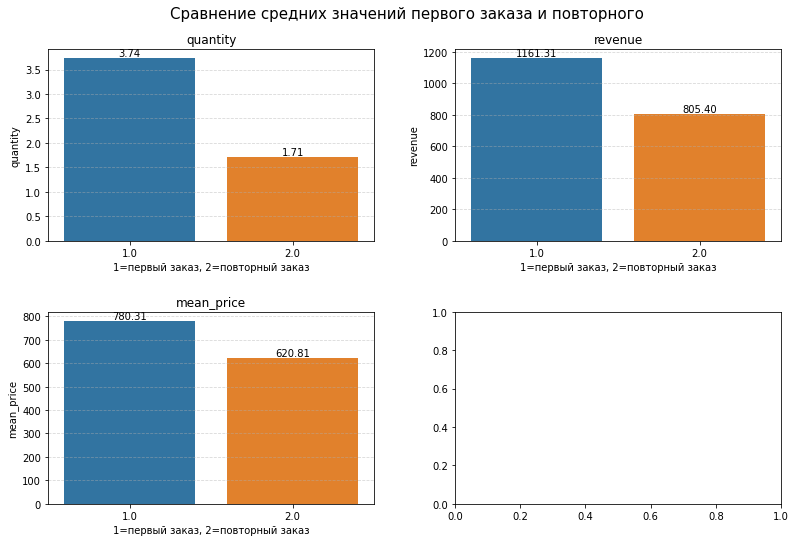

In [97]:
# фильтруем числовые столбцы
metrics = orders_filter.drop(columns=['customer_id','order_id','year_month','date','days_between_orders']).columns

# Создаем сетку графиков
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.tight_layout(pad=5.0)  # Отступы между графиками

# Преобразуем axes в плоский массив для удобного индексирования
axes = axes.flatten()

# Проходим по всем метрикам и строим графики
for i, col in enumerate(metrics):
    ax = axes[i]
    
    # Столбчатая диаграмма
    barplot = sns.barplot(x='days_between_orders', y=col, data=orders_filter, ax=ax, ci=None)
    
    # Добавляем подписи значений
    for p in barplot.patches:
        height = p.get_height()
        barplot.annotate(
            f'{height:.2f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center',
            xytext=(0, 5),
            textcoords='offset points'
        )
    
    # Настройки оформления
    ax.set_title(f'{col}', fontsize=12)
    ax.set_xlabel('1=первый заказ, 2=повторный заказ', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Сравнение средних значений первого заказа и повторного', fontsize=15)
plt.show()

**Наблюдение:**

Значения показателей : средний чек, средний прайс на товар в чеке, среднее кол-во товаров в чеке у повторных заказов ниже, чем у всех первых или разовых.

## Общие выводы:

**Описание проведенных этапов работ**.

**1. Загрузка и предобработка данных.**

 - Колонка с датой была приведена к корректному типу данных.
 - Найдены и устранены дубликаты заказов, анализ проводился по заказам с первичной сформированной датой.
 - Была проведена сегментация товаров по категориям, всего было выделено 14 категорий товаров.

**2. Исследовательский анализ поведения покупателей:**

**Ключевые наблюдения:**

**- Распределение выручки по клиентам:**

- 52.67% покупателей принесли выручку до 900 руб.
- 22.8% — 900–1800 руб., 10% — 1800–2700 руб., остальные — свыше 2700 руб.
- Вывод: Магазин зависит от большого числа мелких покупок, но 14.5% клиентов генерируют значительную долю дохода.

**- Средний чек и аномалии:**

- 51.5% клиентов имеют средний чек до 680 руб., 24% — 680–1360 руб., 11% — 1360–2040 руб.

**- Частота заказов:**

- 63.5% клиентов сделали 1 заказ, 35.27% — 2 заказа, 1.15% — 3+ заказа.
- Проблема: Низкая вовлеченность — большинство покупателей не возвращаются.

**- Количество товаров в чеке:**

- 65% заказов содержат 1 товар, 9% — 2 товара, 4.4% — 3 товара.

**- Интервалы между покупками:**

- 32% повторных покупок совершены в течение 40 дней.
- 17.5% — между 276 и 316 днями (почти год).
- Медианный интервал: 197 дней (6.5 месяцев).
- Корреляция между суммой чека и интервалом отсутствует.

**3. Исследовательский анализ товарных категорий:**


**- Широта ассортимента. Лидеры по количеству SKU:**

- Цветы и растения (485 SKU)
- Рассада и саженцы (450 SKU)
- Товары для кухни (278 SKU)

**- Прибыльные категории (80% выручки):**

- Оборудование для хоз. работ (сумки-тележки, стремянки) — 940 857 руб.
- Сантехникаи всё для ванной— 894 772 руб.
- Сушилки и гладильные доски — 708 069 руб.

**- Больше всего продано (80% количества):**

- Искусственные цветы (2340 шт.)
- Цветы и растения (2236 шт.)
- Рассада и саженцы (1832 шт.)

**Вывод: Магазин продает много недорогих товаров, но прибыль генерируют  категории с высоким прайсом.**

**- Ценовые сегменты. Топ-5 дорогих категорий (по среднему чеку):**

- Бытовая техника — 1199 руб.
- Оборудование для хоз. работ — 1139 руб.
- Мебель и интерьер — 1012 руб.
- Постельное белье — 974 руб.
- Сантехника — 937 руб.

**-Самые дешевые:**

- Рассада и саженцы — 192 руб.
- Искусственные цветы — 155 руб.

**Дорогие категории приносят высокий чек, но низкий объем.**

**Бюджетный сегмент (рассада, цветы) — массовые продажи с минимальной маржой.**

**- Сезонность:**

- Апрель–Май 2019: Пик продаж рассады и саженцев — сезон дачных работ.
- Январь 2019: Спрос на постельное белье — новогодние распродажи или подарки.
- Июнь 2019: Спрос на вешалки и товары для хранения вещей - смена сезонного гардероба

**4. Профили потребления покупателей: ключевые выводы и персонализированные стратегии рекламных рассылок:**

**1. Кластер 0: "Малоактивные покупатели с типичными чеками"**

- Самый массовый сегмент (44% всех клиентов)
- Частота заказов: 1 заказ (разовые покупки)
- Состав заказа: В среднем 3.11 товара в чеке
- Средний чек: 788 руб.
- Средняя цена товара: 460 руб.

Категории, которые принесли  80% прибыли:

- Цветы, растения 
- Сушилки, гладильные доски 
- Оборудование для хоз. работ 
- Товары для кухни 
- Мебель, интерьер, фурнитура
- Сантехника, все для ванной комнаты 
- Вешалки и хранение вещей 

Больше всего было продано в штуках цветов , всё для кухни , рассада  , искуственные цветы.

В динамике продаж по месяцам наблюдается увеличение продаж сезонного товара: рассады и саженцев. Но общая динамика не зависит от этой категории сезонных товаров, весеннего всплеска продаж не наблюдается. С ноября 2019 в данный кластер не попало ни одного покупателя, соответсвенно можно сделать вывод, что профиль потребления начал смещаться в сторону кластеров 1,2 и 3.

**Основная масса разовых покупателей. Делают типичные заказы с несколькими товарами средней ценовой категории. Возможно, это случайные покупатели или те, кто пробует ассортимент.**

**Рекомендации:**

*Цели для кластера:*

Превратить разовых покупателей в постоянных через персонализацию, допродажи и программу лояльности. 

- Через неделю после покупки: Благодарность за покупку + предложить скидку на повторный заказ + предложить дополняющие товары "К вашему товару подойдет это товар".
- Через 30 дней после покупки: Стимул к повторному заказу в виде скидки на товары из первого заказа или похожие товары + дополняющие товары
- Через 3 месяца: Более крупная скидка на  категорию из прошлого заказа или на категории: Цветы, растения, гладильные доски, Оборудование для хоз. работ, Товары для кухни, Мебель, интерьер, фурнитура, все для ванной комнаты, Вешалки и хранение вещей
- Сезонные рассылки. За 2–3 недели до начала сезона напоминание: в марте для категории рассада, в декабре для категории Вешалки и хранение вещей: пример, «Готовы к дачному сезону? Ваша рассада уже ждет!», «уборка перед Новым годом»
- В период сезона предлагать связки товаров: "Саженец  + удобрение + горшок = -25%". Сезон саженцев апрель -май. Сезон хранения вещей январь.
- Программа лояльности: "За каждые 3 покупки — подарок (например, комнатное растение или кухонный аксессуар)".
- Программа лояльности: Накопительные бонусы в виде кэшбэка.
- Регулярые рассылки, каждый месяц, готовые подборки по категориям: гладильные доски, оборудоание для хоз. работ, товары для кухни и для ванной, для хранения и мебель, фурнитура.
- Регулярное информирование о скидках на товары на сайте
- В случае отсутсвия заказов, регулярная рассылка 1 раз в месяц  предложение "Счастливый час": "Только сегодня/7 дней скидка на любой заказ".


**2. Кластер 1: "Лояльные покупатели с концентрированными заказами"**

- Второй по величине сегмент (27% клиентов)
- Частота заказов: 2 заказа на клиента
- Состав заказа: Всего 1.44 товара в заказе (минимальный показатель)
- Средний чек: 693 руб. (самый низкий)
- Средняя цена товара: 635 руб. (выше чем в кластере 0)

Категории, которые принесли  80% прибыли:

- Сушилки, гладильные доски 
- Оборудование для хоз. работ 
- Цветы, растения 
- Мебель, интерьер, фурнитура
- Товары для кухни .
- Сантехника, все для ванной комнаты 

Больше всего было продано в штуках цветов  и рассады.

В апреле и мае наблюдается всплеск сезонных продаж сезонных товаров (рассады) в штуках. Но  в выручке в период с апреля по октябрь происходит падение продаж. Однако важно отметить, что с ноября 2019 года значительный рост продаж с самой большой выручкой. Больше всего выручки в этот период принесли категории: гладильные доски/сушки, сумки тележки /стремянки и инструменты.

**Клиенты делают несколько заказов, но покупают 1-2 более дорогих товара. Возможно, это целенаправленные покупки конкретных товаров.**

**Рекомендации:**

*Цели для кластера:*

- Увеличить частоту покупок – с текущих 2 заказов до 3+ заказов в год на клиента.
- Увеличить количество товара в чеке.
- Укрепить лояльность 
- Оптимизировать сезонные продажи – увеличить выручку в низкий сезон (лето-осень)

Рассылки:
- После 1-го заказа скидка на дополняющие товары
- Через 2-3 недели альтернативы купленных товаров : "Вам понравилась рассада? Попробуйте элитные сорта с гарантией приживаемости!"
- Сезонные рассылки с дополняющими товарами. За 2–3 недели до начала в марте  "Готовьтесь к дачному сезону! Суперцена на рассаду и оборудование для хоз. работ."
- В марте и апреле акция для рассады "купи 3 саженца — 4-й в подарок".
- После спада сезона в июне предложить сопутствующие товары "садовый инвентарь, инструменты по спец цене."
- Регулярые рассылки, каждый месяц, готовые подборки в категориях гладильные доски,хоз. оборудование, для интерьера и фурнитура, для кухни и всё для ванной.
- В период май-октябрь предложить доп. сервис, например, бесплатную доставку за оформление заказа.
- Программа лояльности: "За каждые 4 покупки — подарок (например, комнатное растение или кухонный аксессуар)".
- Программа лояльности: Накопительные бонусы в виде кэшбэка.
- В ноябре-январе спец. предложения на категории гладильные доски/сушки, сумки тележки /стремянки и инструменты.


**3. Кластер 2: "Премиальные покупатели"**

- Небольшая группа (5% клиентов), но ценная
- Частота заказов: 1.35 заказа
- Состав заказа: 1.38 товара в заказе
- Средний чек: 4454 руб. (максимальный)
- Средняя цена товара: 3694 руб. 

Категории, которые принесли  85% прибыли:

- Оборудование для хоз. работ 
- Сушилки, гладильные доски  
- Хоз.товары, для уборки 
- Постельное белье, и текстиль 

Больше всего было продано в штуках тележки и стремянки  , постельное белье  и сушилки/гладильные доски. 

Категория постельное белье имеет сезонность: объемные продажи в январе и июне.

**Делают 1-2 заказа, но покупают очень дорогие товары. Покупатели дорогих категорий.**

*Цели для кластера:*

- Увеличение кол-ва товаров в чеке
- Повышение частоты покупок
- Укрепление лояльности
- Увеличить продажи вне сезона

Рассылки:

- После покупки Благодарность за покупку  + предложить дополняющие товары "К вашему товару подойдет это товар".
- Ежемесячное иформирование о новинках в категориях или рассказывать о преимуществах и качествах товаров в категориях : хозоборудования, сушилки/ гладильные доски, хоз.товары для уборки, постельное белье и текстиль 
- Сезонные рассылки. в декабре и мае, перед сезонными продажами постельного белья, рассылка подборок , новинки, премиальные наборы.
- Сезонные рассылки. в январе и мае скидка на премиальные наборы " постельное белье + дополняющий текстиль"
- Сезонные рассылки. В июле рассылка с наборами по спец условиям "сушилки/гладильные доски + текстиль"
- В январе и сентябре , в период снижения продаж категории хозоборудования скидка, можно подать как "Закрытый аукцион, только для ограниченного круга покупателей"
- В период спада продаж категории текстиля февраль -май, июль-январь скидки на категорию
- Программа лояльности для вип -клиентов, формат закрытого клуба. При выполнении 3 заказов в год - пожизненная скидка.
- Подарки за покупку на сумму от 5000 руб.(цветы)

**4. Кластер 3: "Оптовые покупатели"**

- Самая маленькая группа (4% клиентов), но значимая
- Частота заказов: 1.06 заказа (фактически разовые)
- Состав заказа: 30.5 товара в заказе (аномально много)
- Средний чек: 3240 руб.
- Средняя цена товара: 127 руб. (минимальная)

Категории, которые принесли  80% прибыли:

- Цветы, растения 
- Вешалки и хранение вещей 
- Рассада, саженцы  
- Иcкуственные цветы 
- Товары для кухни 
- Постельное белье, и текстиль	
- Хоз.товары, для уборки  

Больше всего было продано искуственых цветов , рассада , вешалки , цветы.

Явный сезонный всплеск  (апрель-май) продаж сезоных товаров цветов и рассады.

**Покупают очень много дешевых товаров, в том чсиле сезонные цветы и рассаду. Возможно, мелкий опт, розничные перепродавцы или закупки организаций.**


*Цели для кластера:*

- увеличение частоты покупок
- увеличить среднюю цену товара 

Рассылка:

- Сезонные рассылки. За 2–3 недели до начала сезона напоминание: в марте для категории рассада, в ноябре для категории оборудование для хоз работ: пример, «Готовы к дачному сезону? Ваша рассада уже ждет!»
- Также в феврале-марте ранние оптовые скидки, формирование предзаказов на рассаду например. "Спецпредложение : предзаказ рассады со скидкой 25% при заказе от 20 шт."
- Аналогично в январе  формирование предзаказов на искуственные цветы. 
- Октябрь - декабрь дополнительные оптовые скидки на категорию цветы , в период снижения сезона
- Май - октябрь , в период общего падения продаж предложить крупные оптовые наборы по спец. цене в категориях: вешалки и хранение вещей, товары для кухни, текстиль и товары для уборки.